# Task 9.2 — Analisi di correlazione temporale CAMS / Sentinel-5P / Vento

**Obiettivo:** analizzare la correlazione temporale tra i dati del modello **CAMS**, gli indici del **Sentinel-5P (TROPOMI)** e l'**intensità/direzione del vento**, considerando sia il giorno corrente sia i giorni antecedenti (anno 2025).

## Parametri di monitoraggio
| Inquinante | Colonna CAMS | Proxy S5P testati |
|---|---|---|
| **NO₂** | `cams_no2` | NO₂ TROPOMI (misura diretta), Colonna O₃, Aerosol Index, SO₂, HCHO |
| **O₃** | `cams_o3` | Colonna O₃, NO₂ (precursore fotochimico), HCHO (precursore) |
| **PM10** | `cams_pm10` | Aerosol Index, NO₂, SO₂, HCHO |
| **PM2.5** | `cams_pm25` | Aerosol Index, NO₂, SO₂, HCHO |

> ⚠️ Nota: nei CSV le colonne `s5p_pm10` e `s5p_pm25` contengono lo stesso **Aerosol Index** (non esiste una misura diretta del particolato da satellite).

## Metodologia
1. **Confronto istantaneo** — correlazione tra CAMS al giorno *t* e misura satellitare al giorno *t*.
2. **Analisi dei lag** — il **predittore Sentinel-5** viene spostato nel passato (*t−1*, *t−2*, … *t−7*) mentre il target CAMS resta fermo: **lag = L** confronta CAMS(*t*) con S5P(*t−L*), per valutare persistenza degli inquinanti e tempi di risposta.
3. **Medie mobili retrospettive** — finestre da 1 a **14 giorni** (consigliato per gas ad alta variabilità spaziale come NO₂) per ridurre il rumore meteorologico; la finestra copre solo il giorno corrente e i precedenti, **mai giorni futuri**.
4. **Correzione per vento** — esclusione dei giorni con vento > 8 m/s e analisi separata per settore di provenienza (Nord/Est/Sud/Ovest).
5. **Output** — per ogni inquinante si seleziona la combinazione *lag × finestra MA × proxy* con il coefficiente di Pearson più elevato (in valore assoluto), seguita da **analisi di dispersione e best fitting**.

**Dati di input** (stessa cartella del notebook):
- `serie_temporali_giornaliero_corretto.csv` — serie giornaliere 2025 per ~1.250 punti
- `serie_temporali_settimanale.csv` — stesse variabili aggregate a passo settimanale (usato nella sezione finale di confronto)
- `vento_orario_media_pre13.csv` — media dell'intensità del vento nelle 3 e 6 ore precedenti le 13 locali (ora del passaggio del satellite), calcolata dal vento orario ERA5 (Open-Meteo); generata automaticamente dalla sezione 2.1 se assente

Tutti i CSV e i PNG di output vengono salvati nella cartella `risultati_correlazione/`.

## 1. Setup e configurazione

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = False

# ── File di input (stessa cartella del notebook) ─────────────────────────────
CSV_GIORNALIERO = Path("serie_temporali_giornaliero_corretto.csv")
CSV_SETTIMANALE = Path("serie_temporali_settimanale.csv")

# ── Cartella di output per CSV e PNG ─────────────────────────────────────────
OUTPUT_DIR = Path("risultati_correlazione")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Lag (giorni nel passato) e finestre di media mobile (giorni) ─────────────
LAG_STEPS  = list(range(0, 8))          # t, t-1, ..., t-7
MA_WINDOWS = [1, 2, 3, 5, 7, 10, 14]    # fino a 14 giorni (consigliato per NO2)

# ── Vento ─────────────────────────────────────────────────────────────────────
SOGLIA_VENTO_MS = 8.0   # i giorni con vento > 8 m/s vengono esclusi dall'analisi

SETTORI_VENTO = {
    'Nord':  (315, 45),
    'Est':   (45, 135),
    'Sud':   (135, 225),
    'Ovest': (225, 315),
}

COLORI_SETTORI = {'Nord': '#3A7DC9', 'Est': '#E07B39', 'Sud': '#C00000',
                  'Ovest': '#1E6B3C', 'Tutti': '#7B5EA7', 'Sconosciuto': '#888888'}

# ── Inquinanti CAMS e proxy Sentinel-5P da testare ───────────────────────────
VARIABILI = {
    'NO2': {
        'cams_col': 'cams_no2',
        's5p_proxies': {
            'NO2_TROPOMI': 's5p_no2',
            'Colonna_O3':  's5p_o3',
            'Aerosol_Index': 's5p_pm10',
            'SO2_proxy':   's5p_so2',
            'HCHO_proxy':  's5p_hcho',
        },
        'note': 'Misura diretta TROPOMI + confronto con altri indici S5P'
    },
    'O3': {
        'cams_col': 'cams_o3',
        's5p_proxies': {
            'Colonna_O3': 's5p_o3',
            'NO2_proxy':  's5p_no2',
            'HCHO_proxy': 's5p_hcho',
        },
        'note': 'Colonna totale O3; NO2 e HCHO come precursori fotochimici'
    },
    'PM10': {
        'cams_col': 'cams_pm10',
        's5p_proxies': {
            'Aerosol_Index': 's5p_pm10',
            'NO2_proxy':     's5p_no2',
            'SO2_proxy':     's5p_so2',
            'HCHO_proxy':    's5p_hcho',
        },
        'note': 'Test multipli proxy per PM10 (con SO2 e HCHO)'
    },
    'PM25': {
        'cams_col': 'cams_pm25',
        's5p_proxies': {
            'Aerosol_Index': 's5p_pm25',
            'NO2_proxy':     's5p_no2',
            'SO2_proxy':     's5p_so2',
            'HCHO_proxy':    's5p_hcho',
        },
        'note': 'Test multipli proxy per PM2.5 (con SO2 e HCHO)'
    },
}

## 2. Caricamento dati

I CSV usano `;` come separatore e `,` come separatore decimale. Per ogni osservazione viene assegnato il settore di provenienza del vento (Nord/Est/Sud/Ovest).

In [2]:
def carica_dati(path, label, strict=True):
    df = pd.read_csv(path, sep=';', decimal=',')
    df['data'] = pd.to_datetime(df['data'])
    df = df.sort_values(['punto_id', 'data']).reset_index(drop=True)

    # ── Controllo automatico duplicati (data, punto_id) ──────────────
    n_dup = int(df.duplicated(subset=['data', 'punto_id']).sum())
    if n_dup:
        nome = getattr(path, 'name', str(path))
        msg = f"[{label}] {n_dup:,} righe duplicate su (data, punto_id) nel file {nome}"
        if strict:
            raise AssertionError(msg + " — usare il file *_corretto.csv deduplicato.")
        print("  ATTENZIONE: " + msg + " (file settimanale mantenuto come da scelta).")
    else:
        print(f"[{label}] controllo duplicati OK: 0 duplicati su (data, punto_id).")

    # settore di provenienza del vento (vettoriale)
    d = df['vento_direzione'].values
    condizioni = [
        (d >= 315) | (d < 45),
        (d >= 45) & (d < 135),
        (d >= 135) & (d < 225),
        (d >= 225) & (d < 315),
    ]
    df['settore_vento'] = np.select(condizioni, list(SETTORI_VENTO.keys()),
                                    default='Sconosciuto')

    print(f"[{label}] righe: {len(df):,} | punti: {df['punto_id'].nunique():,} | "
          f"date: {df['data'].nunique()} "
          f"({df['data'].min().date()} → {df['data'].max().date()})")
    return df


df_g = carica_dati(CSV_GIORNALIERO, 'GIORNALIERO')
df_s = carica_dati(CSV_SETTIMANALE, 'SETTIMANALE', strict=False)
df_g.head()

[GIORNALIERO] controllo duplicati OK: 0 duplicati su (data, punto_id).
[GIORNALIERO] righe: 454,060 | punti: 1,244 | date: 365 (2025-01-01 → 2025-12-31)
  ATTENZIONE: [SETTIMANALE] 1,244 righe duplicate su (data, punto_id) nel file serie_temporali_settimanale.csv (file settimanale mantenuto come da scelta).
[SETTIMANALE] righe: 67,176 | punti: 1,244 | date: 53 (2024-12-30 → 2025-12-29)


,data,punto_id,lon,lat,vento_velocita,vento_direzione,cams_no2,cams_o3,cams_pm10,cams_pm25,s5p_no2,s5p_o3,s5p_pm10,s5p_pm25,s5p_so2,s5p_hcho,settore_vento
0,2025-01-01,0,10.232089,46.620464,0.522768,357.218583,3.475144,58.784611,8.008161,5.233172,0.000004,0.136898,-1.051497,-1.051497,-0.001182,-0.000157,Nord
1,2025-01-02,0,10.232089,46.620464,1.174397,241.932549,4.949642,45.287086,11.113952,7.663663,-0.000073,0.135235,0.422539,0.422539,-0.003974,-0.000056,Ovest
2,2025-01-03,0,10.232089,46.620464,2.031878,345.311434,4.305604,57.521648,2.802751,2.078778,0.000002,0.145146,-1.335790,-1.335790,-0.000683,-0.000031,Nord
3,2025-01-04,0,10.232089,46.620464,1.123214,6.112173,3.113412,59.081650,4.849936,3.038959,0.000019,0.139672,-1.786310,-1.786310,0.000159,0.000182,Nord
4,2025-01-05,0,10.232089,46.620464,0.562253,242.720073,3.621244,45.857521,7.389281,5.915008,0.000076,0.122971,-1.393908,-1.393908,0.000761,0.000012,Ovest


### 2.1 Vento medio nelle ore precedenti il passaggio del satellite (ore 13)

Il Sentinel-5P passa sull'area di studio intorno alle **ore 13 locali**: la colonna `vento_velocita` del CSV è però un aggregato **giornaliero**, che può essere poco rappresentativo delle condizioni di dispersione al momento della misura satellitare.

Qui si aggiungono al dataset giornaliero due nuove variabili calcolate dal **vento orario ERA5** (archivio Open-Meteo, celle 0.25°):

| Colonna | Definizione |
|---|---|
| `vento_pre13_3h` | media dell'intensità del vento nelle **3 ore precedenti le 13** (10:00–12:59 locali) |
| `vento_pre13_6h` | media dell'intensità del vento nelle **6 ore precedenti le 13** (07:00–12:59 locali) |

Il vento orario viene scaricato una sola volta e salvato in cache nel file `vento_orario_media_pre13.csv` (stessa cartella del notebook): le esecuzioni successive leggono direttamente la cache. Ogni punto eredita il valore della cella 0.25° che lo contiene.

In [3]:
# ── Media del vento nelle 3/6 ore precedenti le 13 (passaggio satellite) ──────
RISOLUZIONE_CELLA = 0.25                                # celle ERA5 [gradi]
CSV_VENTO_PRE13 = Path("vento_orario_media_pre13.csv")  # cache locale


def scarica_vento_pre13(df, path_cache, risoluzione=RISOLUZIONE_CELLA):
    """Scarica il vento orario ERA5 (Open-Meteo) per le celle che coprono i punti
    e calcola la media dell'intensità nelle 3 h (10-13) e 6 h (07-13, ora locale)
    precedenti il passaggio del satellite. Salva il risultato in `path_cache`."""
    import time
    import requests

    celle = (df[['lon', 'lat']].drop_duplicates()
               .assign(glon=lambda d: (d['lon'] / risoluzione).round() * risoluzione,
                       glat=lambda d: (d['lat'] / risoluzione).round() * risoluzione)
               [['glon', 'glat']].drop_duplicates().reset_index(drop=True))
    anno = df['data'].dt.year.iloc[0]
    print(f"Scarico il vento orario ERA5 per {len(celle)} celle ({anno})...")

    righe, batch = [], 16
    for i in range(0, len(celle), batch):
        blocco = celle.iloc[i:i + batch]
        r = requests.get('https://archive-api.open-meteo.com/v1/archive', params={
            'latitude': ','.join(f"{v:.2f}" for v in blocco['glat']),
            'longitude': ','.join(f"{v:.2f}" for v in blocco['glon']),
            'start_date': f"{anno}-01-01", 'end_date': f"{anno}-12-31",
            'hourly': 'wind_speed_10m', 'timezone': 'Europe/Rome',
            'wind_speed_unit': 'ms'}, timeout=180)
        r.raise_for_status()
        risposte = r.json()
        if isinstance(risposte, dict):
            risposte = [risposte]
        for (_, cella), ris in zip(blocco.iterrows(), risposte):
            h = pd.DataFrame({'time': pd.to_datetime(ris['hourly']['time']),
                              'ws': ris['hourly']['wind_speed_10m']})
            h['data'] = h['time'].dt.normalize()
            h['ora'] = h['time'].dt.hour
            d = pd.DataFrame({
                'vento_pre13_3h': h[h['ora'].between(10, 12)].groupby('data')['ws'].mean(),
                'vento_pre13_6h': h[h['ora'].between(7, 12)].groupby('data')['ws'].mean(),
            }).reset_index()
            d['glon'], d['glat'] = cella['glon'], cella['glat']
            righe.append(d)
        time.sleep(1)

    vento = pd.concat(righe, ignore_index=True)
    vento = vento[['glon', 'glat', 'data', 'vento_pre13_3h', 'vento_pre13_6h']]
    vento.to_csv(path_cache, sep=';', decimal=',', index=False,
                 date_format='%Y-%m-%d')
    print(f"Salvata cache: {path_cache} ({len(vento):,} righe)")
    return vento


def aggiungi_vento_pre13(df, risoluzione=RISOLUZIONE_CELLA):
    """Aggiunge a `df` le colonne vento_pre13_3h / vento_pre13_6h (merge per
    cella 0.25° e data). Idempotente: se le colonne esistono già non fa nulla."""
    if 'vento_pre13_3h' in df.columns:
        print("Colonne vento_pre13_* già presenti: merge saltato.")
        return df
    if CSV_VENTO_PRE13.exists():
        vento = pd.read_csv(CSV_VENTO_PRE13, sep=';', decimal=',')
        vento['data'] = pd.to_datetime(vento['data'])
    else:
        vento = scarica_vento_pre13(df, CSV_VENTO_PRE13, risoluzione)

    # indici interi di cella per un merge robusto (niente confronti tra float)
    vento['ilon'] = (vento['glon'] / risoluzione).round().astype(int)
    vento['ilat'] = (vento['glat'] / risoluzione).round().astype(int)
    df = df.assign(ilon=(df['lon'] / risoluzione).round().astype(int),
                   ilat=(df['lat'] / risoluzione).round().astype(int))
    df = df.merge(vento[['ilon', 'ilat', 'data', 'vento_pre13_3h', 'vento_pre13_6h']],
                  on=['ilon', 'ilat', 'data'], how='left').drop(columns=['ilon', 'ilat'])

    n_nan = df['vento_pre13_3h'].isna().sum()
    print(f"Aggiunte vento_pre13_3h / vento_pre13_6h: {len(df):,} righe, "
          f"{n_nan:,} valori mancanti")
    return df


df_g = aggiungi_vento_pre13(df_g)
df_g[['data', 'punto_id', 'vento_velocita', 'vento_pre13_3h', 'vento_pre13_6h']].head()

Aggiunte vento_pre13_3h / vento_pre13_6h: 454,060 righe, 0 valori mancanti


,data,punto_id,vento_velocita,vento_pre13_3h,vento_pre13_6h
0,2025-01-01,0,0.522768,0.416667,0.373333
1,2025-01-02,0,1.174397,2.453333,2.190000
2,2025-01-03,0,2.031878,2.483333,2.323333
3,2025-01-04,0,1.123214,0.850000,0.695000
4,2025-01-05,0,0.562253,2.056667,2.050000


### 2.2 Il vento accumulato pre-13 correla con l'indice S5P meglio del vento giornaliero?

**Ipotesi da verificare:** la colonna di inquinante osservata dal satellite alle ~13:00 dipende dalla *ventilazione pregressa* (vento accumulato nelle ore precedenti il passaggio) più che dal vento medio giornaliero. Se vero, `vento_pre13_3h`/`vento_pre13_6h` devono correlare con gli indici S5P meglio della baseline `vento_velocita`.

Le colonne `s5p_*` del CSV giornaliero sono già la misura del passaggio delle ~13:00 (un overpass al giorno), quindi l'associazione giorno/pixel vento ↔ indice è diretta.

1. **Grafico 1 — distribuzioni**: istogramma sovrapposto delle tre metriche di vento, con la soglia 8 m/s; le finestre pre-13 includono le ore convettive e spostano la distribuzione verso valori più alti.
2. **Grafico 2 — dispersione**: indice S5P alle 13:00 (x) vs vento medio nella finestra (y) per **NO₂ e O₃**, tre serie per pannello (giornaliero come riferimento, 3 h e 6 h pre-13) con r di Pearson in legenda.
3. **Grafico 3 — confronto correlazioni** (grafico chiave): r tra ciascun indice S5P e ciascuna metrica di vento, affiancati per finestra.

L'impatto della soglia a 8 m/s sulle tre definizioni di vento è trattato a parte in § 2.3 (analisi accessoria).

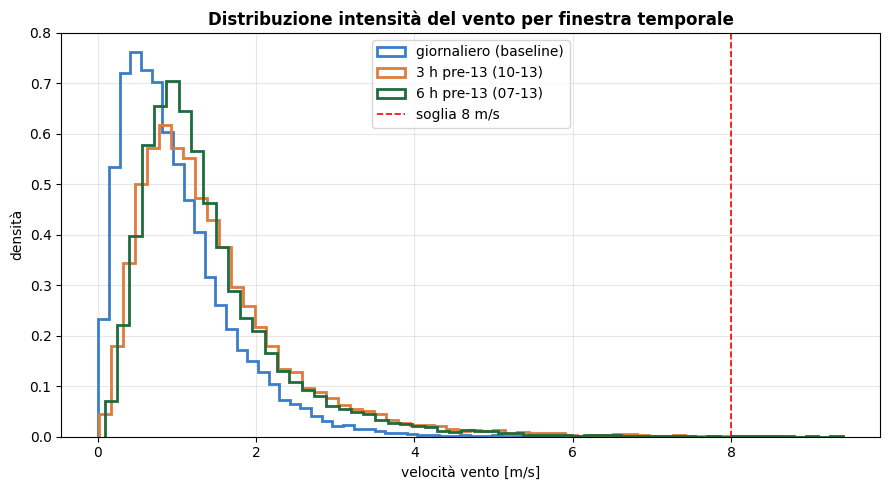

       vento_velocita  vento_pre13_3h  vento_pre13_6h
count       452816.00       454060.00       454060.00
mean             0.99            1.46            1.40
std              0.72            1.03            0.94
min              0.01            0.02            0.09
25%              0.47            0.78            0.79
50%              0.82            1.21            1.16
75%              1.31            1.83            1.72
max              8.06            9.07            9.41


In [4]:
# ── Grafico 1: distribuzione delle tre metriche di vento ─────────────────────
METRICHE_VENTO = [('vento_velocita', 'giornaliero (baseline)', '#3A7DC9'),
                  ('vento_pre13_3h', '3 h pre-13 (10-13)', '#E07B39'),
                  ('vento_pre13_6h', '6 h pre-13 (07-13)', '#1E6B3C')]

fig, ax = plt.subplots(figsize=(9, 5))
for col, lab, colore in METRICHE_VENTO:
    ax.hist(df_g[col].dropna(), bins=60, histtype='step', lw=2,
            color=colore, label=lab, density=True)
ax.axvline(SOGLIA_VENTO_MS, color='red', ls='--', lw=1.2,
           label=f'soglia {SOGLIA_VENTO_MS:.0f} m/s')
ax.set_xlabel('velocità vento [m/s]')
ax.set_ylabel('densità')
ax.set_title('Distribuzione intensità del vento per finestra temporale',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vento_pre13_distribuzioni.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_g[[c for c, _, _ in METRICHE_VENTO]].describe().round(2).to_string())

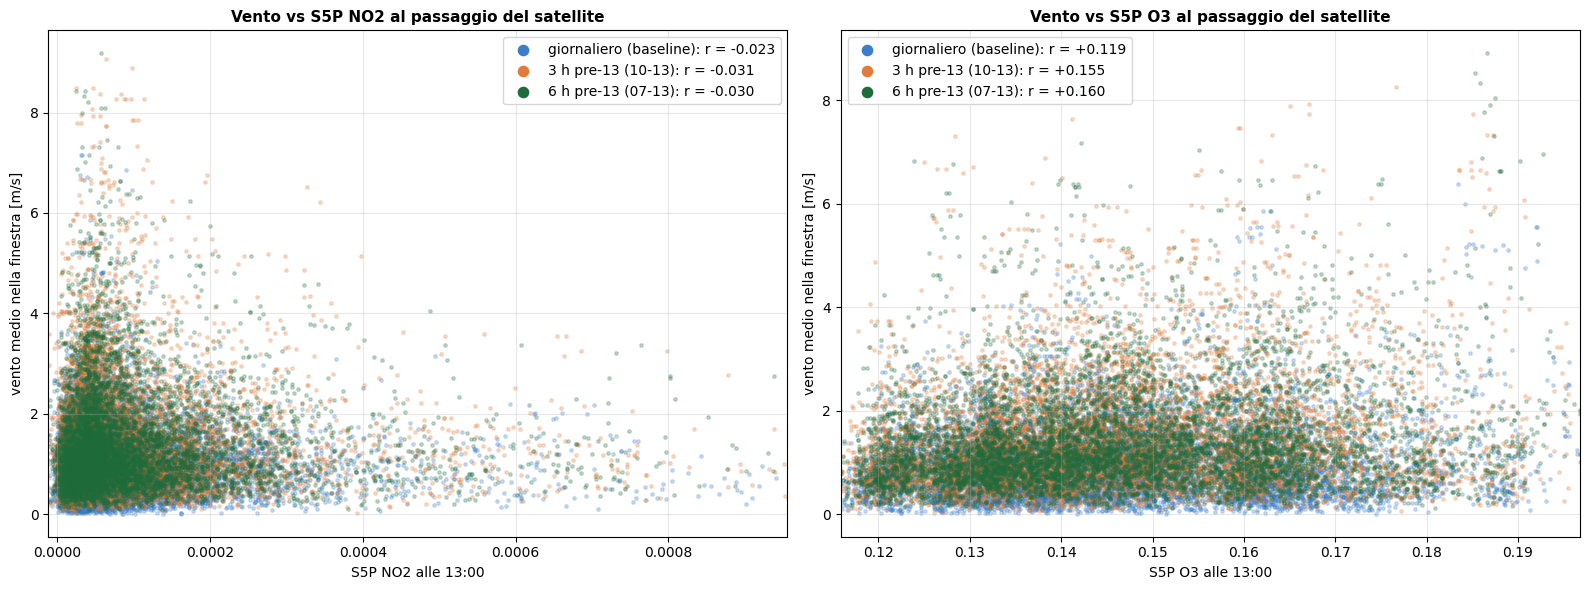

In [5]:
# ── Grafico 2: indici S5P alle 13:00 vs vento medio nella finestra ───────────
INDICI_S5P_SCATTER = ['s5p_no2', 's5p_o3']
ETICHETTE_S5P = {'s5p_no2': 'S5P NO2', 's5p_o3': 'S5P O3', 's5p_pm10': 'S5P AI',
                 's5p_so2': 'S5P SO2', 's5p_hcho': 'S5P HCHO'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
rng = np.random.default_rng(42)
for ax, indice in zip(axes, INDICI_S5P_SCATTER):
    for col, lab, colore in METRICHE_VENTO:
        d = df_g[[indice, col]].dropna()
        r = d[indice].corr(d[col])
        idx = rng.choice(len(d), min(8000, len(d)), replace=False)
        ax.scatter(d[indice].values[idx], d[col].values[idx], s=6, alpha=0.25,
                   color=colore, label=f'{lab}: r = {r:+.3f}', rasterized=True)
    # limiti x sui percentili per non far schiacciare il grafico dagli outlier
    ax.set_xlim(np.nanpercentile(df_g[indice], 0.2),
                np.nanpercentile(df_g[indice], 99.8))
    ax.set_xlabel(f'{ETICHETTE_S5P[indice]} alle 13:00')
    ax.set_ylabel('vento medio nella finestra [m/s]')
    ax.set_title(f'Vento vs {ETICHETTE_S5P[indice]} al passaggio del satellite',
                 fontsize=11, fontweight='bold')
    leg = ax.legend(markerscale=3)
    for h in leg.legend_handles:
        h.set_alpha(1)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vento_pre13_scatter_s5p.png', dpi=150, bbox_inches='tight')
plt.show()

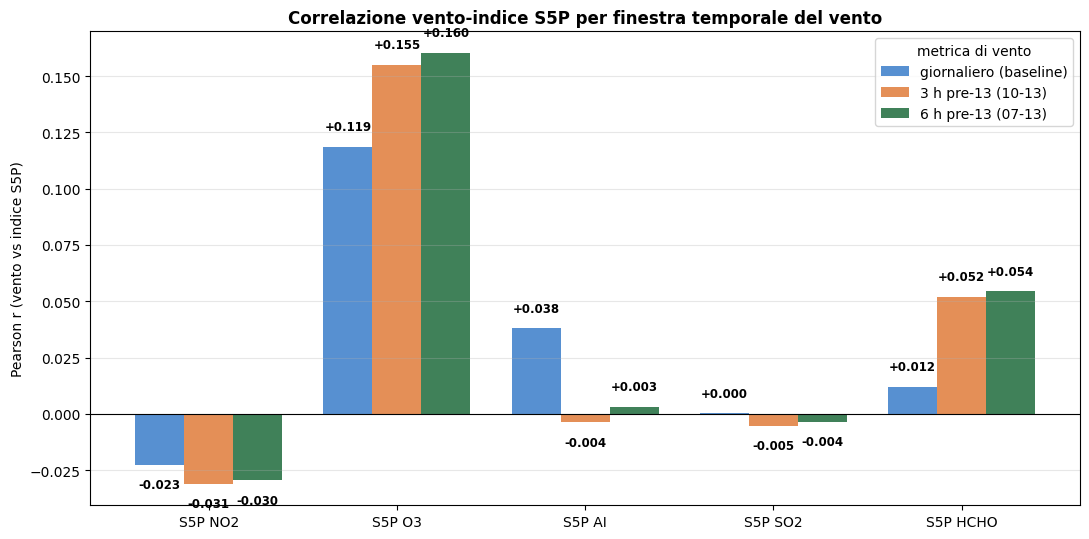

Finestra con |r| massimo per ciascun indice S5P:
  indice          metrica_vento         r
 S5P NO2     3 h pre-13 (10-13) -0.031053
  S5P O3     6 h pre-13 (07-13)  0.160281
  S5P AI giornaliero (baseline)  0.038021
 S5P SO2     3 h pre-13 (10-13) -0.005348
S5P HCHO     6 h pre-13 (07-13)  0.054351


In [6]:
# ── Grafico 3 (chiave): r tra ogni indice S5P e le tre metriche di vento ─────
INDICI_S5P = ['s5p_no2', 's5p_o3', 's5p_pm10', 's5p_so2', 's5p_hcho']

righe = []
for ind in INDICI_S5P:
    for col, lab, _ in METRICHE_VENTO:
        d = df_g[[ind, col]].dropna()
        righe.append({'indice': ETICHETTE_S5P[ind], 'metrica_vento': lab,
                      'r': d[ind].corr(d[col]), 'n': len(d)})
corr_vento_s5p = pd.DataFrame(righe)
corr_vento_s5p.to_csv(OUTPUT_DIR / 'vento_pre13_correlazioni_s5p.csv',
                      sep=';', decimal=',', index=False)

pivot = corr_vento_s5p.pivot(index='indice', columns='metrica_vento', values='r')
pivot = pivot.reindex([ETICHETTE_S5P[i] for i in INDICI_S5P])
pivot = pivot[[lab for _, lab, _ in METRICHE_VENTO]]

fig, ax = plt.subplots(figsize=(11, 5.5))
xpos = np.arange(len(pivot))
larghezza = 0.26
for k, (col, lab, colore) in enumerate(METRICHE_VENTO):
    vals = pivot[lab].values
    bars = ax.bar(xpos + (k - 1) * larghezza, vals, larghezza, label=lab,
                  color=colore, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.006 * np.sign(v),
                f'{v:+.3f}', ha='center', va='bottom' if v >= 0 else 'top',
                fontsize=8.5, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xpos)
ax.set_xticklabels(pivot.index)
ax.set_ylabel('Pearson r (vento vs indice S5P)')
ax.set_title('Correlazione vento-indice S5P per finestra temporale del vento',
             fontsize=12, fontweight='bold')
ax.legend(title='metrica di vento')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vento_pre13_correlazioni_s5p.png', dpi=150, bbox_inches='tight')
plt.show()

# quale finestra vince (in |r|) per ciascun indice
vincitori = corr_vento_s5p.loc[corr_vento_s5p.groupby('indice')['r']
                               .transform(lambda s: s.abs() == s.abs().max()),
                               ['indice', 'metrica_vento', 'r']]
print('Finestra con |r| massimo per ciascun indice S5P:')
print(vincitori.to_string(index=False))

### 2.3 Analisi accessoria — impatto della soglia 8 m/s sulle tre definizioni di vento

Percentuale di osservazioni escluse dal filtro vento > 8 m/s per ciascuna definizione. Serve solo a valutare la robustezza del filtro (le finestre pre-13, più ventose, escludono qualche osservazione in più): non risponde alla domanda vento ↔ indice del § 2.2.

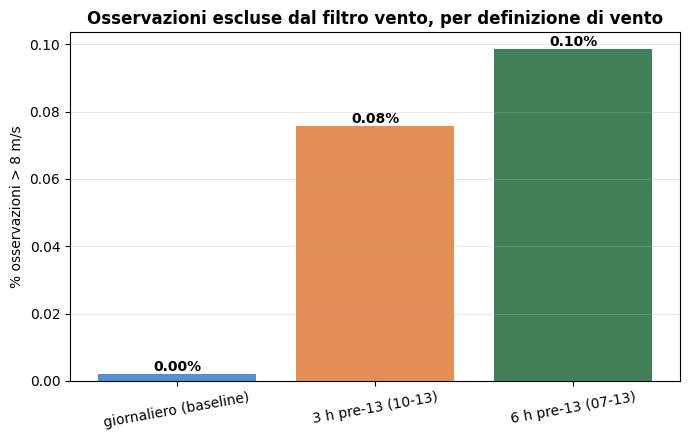

In [7]:
# ── Quota di osservazioni sopra la soglia per ciascuna definizione di vento ──
quote = [(df_g[col] > SOGLIA_VENTO_MS).mean() * 100 for col, _, _ in METRICHE_VENTO]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar([lab for _, lab, _ in METRICHE_VENTO], quote,
              color=[c for _, _, c in METRICHE_VENTO], alpha=0.85)
for bar, q in zip(bars, quote):
    ax.text(bar.get_x() + bar.get_width() / 2, q, f'{q:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel(f'% osservazioni > {SOGLIA_VENTO_MS:.0f} m/s')
ax.set_title('Osservazioni escluse dal filtro vento, per definizione di vento',
             fontweight='bold')
ax.tick_params(axis='x', rotation=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vento_pre13_soglia.png', dpi=150, bbox_inches='tight')
plt.show()

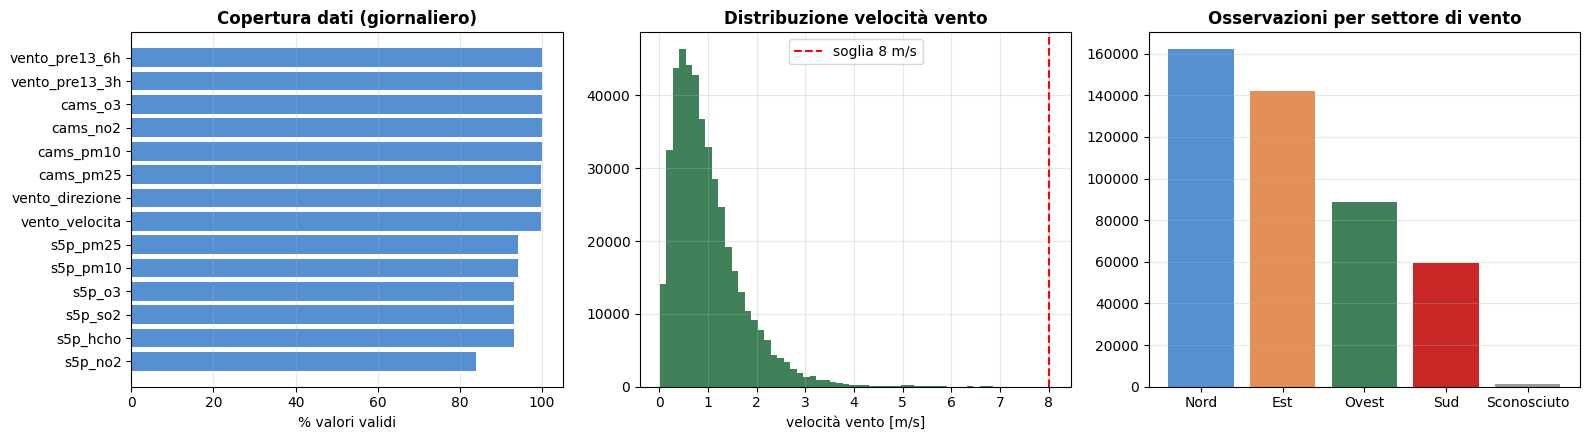

Osservazioni escluse per vento > 8 m/s: 0.00%


In [8]:
# ── Panoramica: copertura dati, distribuzione del vento, settori ─────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

col_dati = [c for c in df_g.columns if c.startswith(('cams_', 's5p_', 'vento_'))]
copertura = df_g[col_dati].notna().mean().sort_values() * 100
axes[0].barh(copertura.index, copertura.values, color='#3A7DC9', alpha=0.85)
axes[0].set_xlabel('% valori validi')
axes[0].set_title('Copertura dati (giornaliero)', fontweight='bold')
axes[0].set_xlim(0, 105)
axes[0].grid(axis='x', alpha=0.3)

axes[1].hist(df_g['vento_velocita'].dropna(), bins=60, color='#1E6B3C', alpha=0.85)
axes[1].axvline(SOGLIA_VENTO_MS, color='red', ls='--',
                label=f'soglia {SOGLIA_VENTO_MS:.0f} m/s')
axes[1].set_xlabel('velocità vento [m/s]')
axes[1].set_title('Distribuzione velocità vento', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

conteggi = df_g['settore_vento'].value_counts()
axes[2].bar(conteggi.index, conteggi.values,
            color=[COLORI_SETTORI.get(s, '#888888') for s in conteggi.index], alpha=0.85)
axes[2].set_title('Osservazioni per settore di vento', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'panoramica_dati.png', dpi=150, bbox_inches='tight')
plt.show()

quota_esclusa = (df_g['vento_velocita'] > SOGLIA_VENTO_MS).mean() * 100
print(f"Osservazioni escluse per vento > {SOGLIA_VENTO_MS:.0f} m/s: {quota_esclusa:.2f}%")

## 3. Funzioni di analisi

Con ~455.000 righe × 8 lag × 7 finestre MA × 12 coppie CAMS/proxy, il calcolo punto-per-punto in un ciclo Python sarebbe molto lento. Le funzioni seguenti sono **vettorializzate**:

- `media_mobile` — media mobile **retrospettiva (trailing)** calcolata separatamente per ogni punto (`groupby('punto_id')`), con cache per non ricalcolare le stesse combinazioni; usa solo il giorno *t* e i precedenti, **mai giorni futuri**;
- `applica_lag` — sposta il **predittore Sentinel-5** di *lag* step nel passato, punto per punto (`groupby.shift`): al giorno *t* associa il valore S5P del giorno *t−lag*, lasciando fermo il target CAMS;
- `pearson_per_punto` — coefficiente di Pearson calcolato **per ogni punto** in un solo passaggio usando le somme di gruppo ( r = (n·Σxy − Σx·Σy) / √[(n·Σx² − (Σx)²)(n·Σy² − (Σy)²)] );
- `analisi_lag_ma` — matrice lag × finestra MA con r medio (± dev. std.) sui punti, escludendo i giorni con vento > 8 m/s; **lag = L** confronta il target CAMS(*t*) con S5P(*t−L*);
- `analisi_per_settore` — r medio per settore di provenienza del vento, alla combinazione lag/MA ottimale.

In [9]:
def media_mobile(df, col, finestra, cache):
    # media mobile retrospettiva (trailing) per punto, con cache (chiave: colonna+finestra):
    # usa solo il giorno t e i giorni precedenti, mai giorni futuri.
    chiave = (col, finestra)
    if chiave not in cache:
        if finestra <= 1:
            cache[chiave] = df[col].astype(float)
        else:
            cache[chiave] = (
                df.groupby('punto_id')[col]
                  .transform(lambda s: s.rolling(finestra, center=False,
                                                 min_periods=max(1, finestra // 2)).mean())
            )
    return cache[chiave]


def applica_lag(serie, punto_id, lag):
    # sposta la serie di `lag` step nel passato, separatamente per ogni punto.
    # Applicata ai PREDITTORI Sentinel-5: al giorno t porta il valore S5P del
    # giorno t-lag (shift positivo), lasciando fermo il target CAMS.
    if lag == 0:
        return serie
    return serie.groupby(punto_id).shift(lag)


def pearson_per_punto(x, y, gruppi, min_n=15):
    # Pearson r per ogni punto, calcolato in modo vettoriale via somme di gruppo
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    validi = np.isfinite(x) & np.isfinite(y)
    if validi.sum() == 0:
        return pd.Series(dtype=float)
    d = pd.DataFrame({'g': np.asarray(gruppi)[validi], 'x': x[validi], 'y': y[validi]})
    d['xx'] = d['x'] * d['x']
    d['yy'] = d['y'] * d['y']
    d['xy'] = d['x'] * d['y']
    g = d.groupby('g', sort=False)
    agg = g[['x', 'y', 'xx', 'yy', 'xy']].sum()
    n = g.size()
    agg, n = agg[n >= min_n], n[n >= min_n]
    if agg.empty:
        return pd.Series(dtype=float)
    num = n * agg['xy'] - agg['x'] * agg['y']
    den = np.sqrt((n * agg['xx'] - agg['x'] ** 2) * (n * agg['yy'] - agg['y'] ** 2))
    return (num / den.where(den > 0)).dropna()


def analisi_lag_ma(df, cams_col, s5p_col, lag_steps, ma_windows, cache):
    # matrice lag x MA: r medio sui punti, con esclusione vento > soglia.
    # Il target CAMS del giorno t resta fermo; il predittore S5P viene spostato
    # con shift(lag), cosi' lag=L confronta CAMS(t) con S5P(t-L).
    vento_ok = ~(df['vento_velocita'] > SOGLIA_VENTO_MS)   # i NaN vento restano inclusi
    punto = df['punto_id']
    righe = []
    for ma in ma_windows:
        cams_ma = media_mobile(df, cams_col, ma, cache).where(vento_ok)   # target fermo
        s5p_ma  = media_mobile(df, s5p_col, ma, cache)
        for lag in lag_steps:
            s5p_lag = applica_lag(s5p_ma, punto, lag).where(vento_ok)     # predittore spostato
            r = pearson_per_punto(cams_ma.values, s5p_lag.values, punto.values)
            if len(r):
                righe.append({'lag': lag, 'ma_window': ma,
                              'r_medio': r.mean(), 'r_std': r.std(ddof=0),
                              'n_punti': len(r)})
    return pd.DataFrame(righe)


def analisi_per_settore(df, cams_col, s5p_col, lag_ott, ma_ott, cache):
    # r medio per settore di vento alla combinazione lag/MA ottimale.
    # Target CAMS(t) fermo; predittore S5P spostato di lag_ott nel passato.
    vento_ok = ~(df['vento_velocita'] > SOGLIA_VENTO_MS)
    punto = df['punto_id']
    cams_ma = media_mobile(df, cams_col, ma_ott, cache)
    s5p_lag = applica_lag(media_mobile(df, s5p_col, ma_ott, cache), punto, lag_ott)
    righe = []
    for settore in list(SETTORI_VENTO.keys()) + ['Tutti']:
        mask = vento_ok if settore == 'Tutti' else vento_ok & (df['settore_vento'] == settore)
        r = pearson_per_punto(cams_ma.where(mask).values,
                              s5p_lag.where(mask).values, punto.values, min_n=5)
        if len(r):
            righe.append({'settore': settore, 'r_medio': r.mean(),
                          'r_std': r.std(ddof=0), 'n_punti': len(r)})
    return pd.DataFrame(righe)

## 4. Matrice di correlazione tra tutte le variabili

Passo preliminare: correlazione di Pearson sui **dati grezzi** (nessun lag, nessuna media mobile) tra tutte le variabili CAMS, S5P e il vento, per una prima visione d'insieme delle relazioni.

In [10]:
def matrice_correlazione_variabili(df, titolo, nome_file):
    candidate = ['cams_no2', 'cams_o3', 'cams_pm10', 'cams_pm25',
                 's5p_no2', 's5p_o3', 's5p_pm10', 's5p_so2', 's5p_hcho',
                 'vento_velocita']
    cols = [c for c in candidate if c in df.columns]
    labels_map = {'cams_no2': 'CAMS NO2', 'cams_o3': 'CAMS O3',
                  'cams_pm10': 'CAMS PM10', 'cams_pm25': 'CAMS PM2.5',
                  's5p_no2': 'S5P NO2', 's5p_o3': 'S5P O3',
                  's5p_pm10': 'S5P AI', 's5p_so2': 'S5P SO2',
                  's5p_hcho': 'S5P HCHO', 'vento_velocita': 'Vento'}
    labels = [labels_map[c] for c in cols]

    corr = df[cols].corr(method='pearson')
    corr_lab = corr.copy()
    corr_lab.columns = labels
    corr_lab.index = labels
    corr_lab.to_csv(OUTPUT_DIR / f"{nome_file}.csv", sep=';', decimal=',')

    fig, ax = plt.subplots(figsize=(11, 9))
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    im = ax.imshow(corr.values, cmap=plt.cm.RdBu_r, norm=norm, aspect='auto')
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = corr.values[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11,
                    color='white' if abs(val) > 0.6 else 'black',
                    fontweight='bold' if i != j else 'normal')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(labels, fontsize=12)
    plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.85)
    ax.set_title(f'{titolo}\n(dati grezzi, n={len(df):,} osservazioni)',
                 fontsize=12, fontweight='bold', color='#1F4E79', pad=15)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{nome_file}.png", dpi=180, bbox_inches='tight')
    plt.show()
    return corr_lab


def plot_matrice_lag_ma(df_ris, var_label, proxy_name, etichetta, unita='giorni'):
    # heatmap lag x MA con evidenziazione della cella ottimale
    pivot = df_ris.pivot(index='lag', columns='ma_window', values='r_medio')
    fig, ax = plt.subplots(figsize=(12, 5.5))
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    cmap = plt.cm.Greens if var_label == 'O3' else plt.cm.RdYlGn
    im = ax.imshow(pivot.values, cmap=cmap, norm=norm, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"MA {c}" for c in pivot.columns], rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"lag {r}" for r in pivot.index])
    ax.set_xlabel(f"Finestra media mobile [{unita}]")
    ax.set_ylabel(f"Lag S5p [{unita} nel passato]")
    ax.set_title(f"Correlazione CAMS vs S5P — {var_label} [{proxy_name}] ({etichetta})\n"
                 f"Pearson r medio su {df_ris['n_punti'].max()} punti | vento ≤ {SOGLIA_VENTO_MS:.0f} m/s",
                 fontsize=11, fontweight='bold')

    max_abs = np.nanmax(np.abs(pivot.values))
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                evidenzia = abs(val) == max_abs
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=14,
                        color='black' if var_label == 'O3' else ('white' if abs(val) > 0.6 else 'black'),
                        fontweight='bold' if evidenzia else 'normal')
                if evidenzia:
                    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                               edgecolor='blue', lw=2.5))

    plt.colorbar(im, ax=ax, label='Pearson r')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"matrice_{etichetta}_{var_label}_{proxy_name}.png",
                dpi=150, bbox_inches='tight')
    plt.show()


def esegui_analisi(df, variabili, lag_steps, ma_windows, etichetta,
                   mostra_grafici=True, unita='giorni'):
    # pipeline completa: per ogni inquinante testa tutti i proxy S5P
    cache = {}
    risultati = {}
    riepilogo = []

    for var_label, cfg in variabili.items():
        print(f"\n{'=' * 62}")
        print(f"  {var_label} — {cfg['note']}")
        print(f"{'=' * 62}")
        best_per_proxy = []

        for proxy_name, s5p_col in cfg['s5p_proxies'].items():
            if s5p_col not in df.columns:
                print(f"  [SKIP] {proxy_name}: colonna '{s5p_col}' assente nel CSV")
                continue
            df_ris = analisi_lag_ma(df, cfg['cams_col'], s5p_col,
                                    lag_steps, ma_windows, cache)
            if df_ris.empty:
                print(f"  [WARN] {proxy_name}: dati insufficienti")
                continue

            risultati[(var_label, proxy_name)] = df_ris
            df_ris.to_csv(OUTPUT_DIR / f"matrice_{etichetta}_{var_label}_{proxy_name}.csv",
                          sep=';', decimal=',', index=False)

            ott = df_ris.loc[df_ris['r_medio'].abs().idxmax()]
            print(f"  {proxy_name:14s} → ottimale: lag={int(ott['lag'])}, "
                  f"MA={int(ott['ma_window'])} | r={ott['r_medio']:+.4f} "
                  f"(±{ott['r_std']:.3f}, {int(ott['n_punti'])} punti)")
            best_per_proxy.append({'proxy_s5p': proxy_name, 's5p_col': s5p_col,
                                   'r_ottimale': ott['r_medio'], 'r_std': ott['r_std'],
                                   'lag': int(ott['lag']), 'ma': int(ott['ma_window'])})
            if mostra_grafici:
                plot_matrice_lag_ma(df_ris, var_label, proxy_name, etichetta, unita)

        if best_per_proxy:
            df_proxy = pd.DataFrame(best_per_proxy)
            risultati[(var_label, '_confronto_proxy')] = df_proxy
            best = df_proxy.loc[df_proxy['r_ottimale'].abs().idxmax()]
            riepilogo.append({'variabile': var_label,
                              'proxy_ottimale': best['proxy_s5p'],
                              's5p_col': best['s5p_col'],
                              'lag_ottimale': int(best['lag']),
                              'ma_ottimale': int(best['ma']),
                              'r_ottimale': round(best['r_ottimale'], 4),
                              'r_std': round(best['r_std'], 4),
                              'n_proxy_testati': len(df_proxy)})

    return risultati, pd.DataFrame(riepilogo), cache

## 5. Analisi lag × media mobile (dato giornaliero)

Per ogni inquinante e per ogni proxy S5P viene generata la **matrice di correlazione lag × finestra MA**: ogni cella è l'r di Pearson medio sui punti (vento ≤ 8 m/s). La cella con |r| massimo identifica la finestra temporale ottimale.

**Convenzione dei lag:** *lag = L* confronta il target **CAMS del giorno *t*** con il predittore **Sentinel-5 del giorno *t−L***. Il target CAMS resta fermo; lo `shift(L)` è applicato solo ai predittori S5P. La media mobile è retrospettiva: per il predittore la finestra di ampiezza *W* copre l'intervallo *[t−L−(W−1), t−L]* e non usa mai giorni futuri.

In [11]:
def plot_matrice_lag_ma(df_ris, var_label, proxy_name, etichetta, unita='giorni'):
    # heatmap lag x MA con evidenziazione della cella ottimale
    pivot = df_ris.pivot(index='lag', columns='ma_window', values='r_medio')
    fig, ax = plt.subplots(figsize=(12, 5.5))
    norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    cmap = plt.cm.Greens if var_label == 'O3' else plt.cm.RdYlGn
    im = ax.imshow(pivot.values, cmap=cmap, norm=norm, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"MA {c}" for c in pivot.columns], rotation=45, ha='right')
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"lag {r}" for r in pivot.index])
    ax.set_xlabel(f"Finestra media mobile [{unita}]")
    ax.set_ylabel(f"Lag S5P [{unita} nel passato]")
    ax.set_title(f"Correlazione CAMS vs S5P — {var_label} [{proxy_name}] ({etichetta})\n"
                 f"Pearson r medio su {df_ris['n_punti'].max()} punti | vento ≤ {SOGLIA_VENTO_MS:.0f} m/s",
                 fontsize=11, fontweight='bold')

    max_abs = np.nanmax(np.abs(pivot.values))
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                evidenzia = abs(val) == max_abs
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=14,
                        color='black' if var_label == 'O3' else ('white' if abs(val) > 0.6 else 'black'),
                        fontweight='bold' if evidenzia else 'normal')
                if evidenzia:
                    ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                               edgecolor='blue', lw=2.5))

    plt.colorbar(im, ax=ax, label='Pearson r')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"matrice_{etichetta}_{var_label}_{proxy_name}.png",
                dpi=150, bbox_inches='tight')
    plt.show()


def esegui_analisi(df, variabili, lag_steps, ma_windows, etichetta,
                   mostra_grafici=True, unita='giorni'):
    # pipeline completa: per ogni inquinante testa tutti i proxy S5P
    cache = {}
    risultati = {}
    riepilogo = []

    for var_label, cfg in variabili.items():
        print(f"\n{'=' * 62}")
        print(f"  {var_label} — {cfg['note']}")
        print(f"{'=' * 62}")
        best_per_proxy = []

        for proxy_name, s5p_col in cfg['s5p_proxies'].items():
            if s5p_col not in df.columns:
                print(f"  [SKIP] {proxy_name}: colonna '{s5p_col}' assente nel CSV")
                continue
            df_ris = analisi_lag_ma(df, cfg['cams_col'], s5p_col,
                                    lag_steps, ma_windows, cache)
            if df_ris.empty:
                print(f"  [WARN] {proxy_name}: dati insufficienti")
                continue

            risultati[(var_label, proxy_name)] = df_ris
            df_ris.to_csv(OUTPUT_DIR / f"matrice_{etichetta}_{var_label}_{proxy_name}.csv",
                          sep=';', decimal=',', index=False)

            ott = df_ris.loc[df_ris['r_medio'].abs().idxmax()]
            print(f"  {proxy_name:14s} → ottimale: lag={int(ott['lag'])}, "
                  f"MA={int(ott['ma_window'])} | r={ott['r_medio']:+.4f} "
                  f"(±{ott['r_std']:.3f}, {int(ott['n_punti'])} punti)")
            best_per_proxy.append({'proxy_s5p': proxy_name, 's5p_col': s5p_col,
                                   'r_ottimale': ott['r_medio'], 'r_std': ott['r_std'],
                                   'lag': int(ott['lag']), 'ma': int(ott['ma_window'])})
            if mostra_grafici:
                plot_matrice_lag_ma(df_ris, var_label, proxy_name, etichetta, unita)

        if best_per_proxy:
            df_proxy = pd.DataFrame(best_per_proxy)
            risultati[(var_label, '_confronto_proxy')] = df_proxy
            best = df_proxy.loc[df_proxy['r_ottimale'].abs().idxmax()]
            riepilogo.append({'variabile': var_label,
                              'proxy_ottimale': best['proxy_s5p'],
                              's5p_col': best['s5p_col'],
                              'lag_ottimale': int(best['lag']),
                              'ma_ottimale': int(best['ma']),
                              'r_ottimale': round(best['r_ottimale'], 4),
                              'r_std': round(best['r_std'], 4),
                              'n_proxy_testati': len(df_proxy)})

    return risultati, pd.DataFrame(riepilogo), cache


  NO2 — Misura diretta TROPOMI + confronto con altri indici S5P
  NO2_TROPOMI    → ottimale: lag=7, MA=14 | r=+0.8420 (±0.119, 1244 punti)


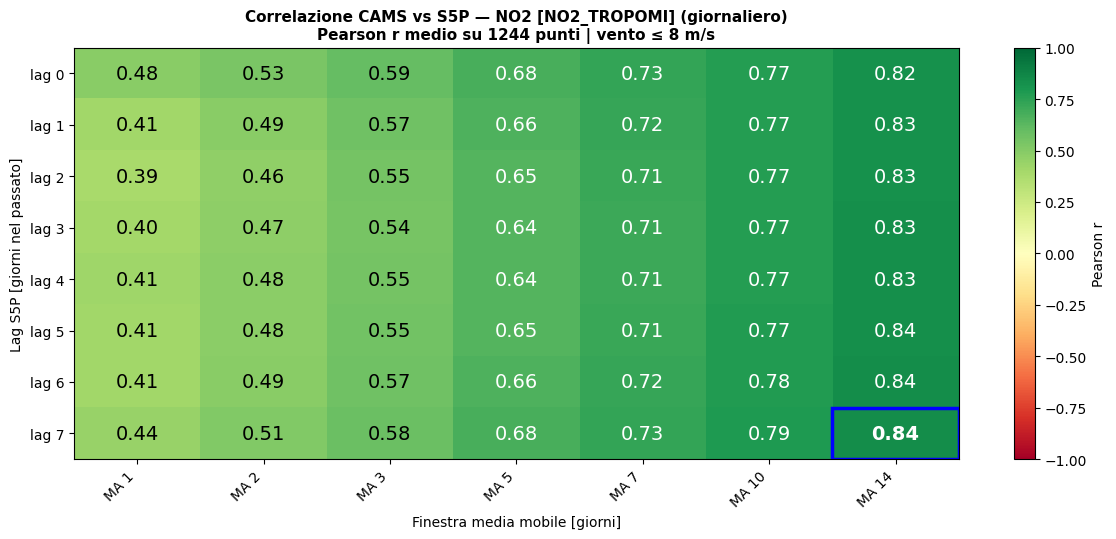

  Colonna_O3     → ottimale: lag=7, MA=14 | r=-0.0584 (±0.125, 1244 punti)


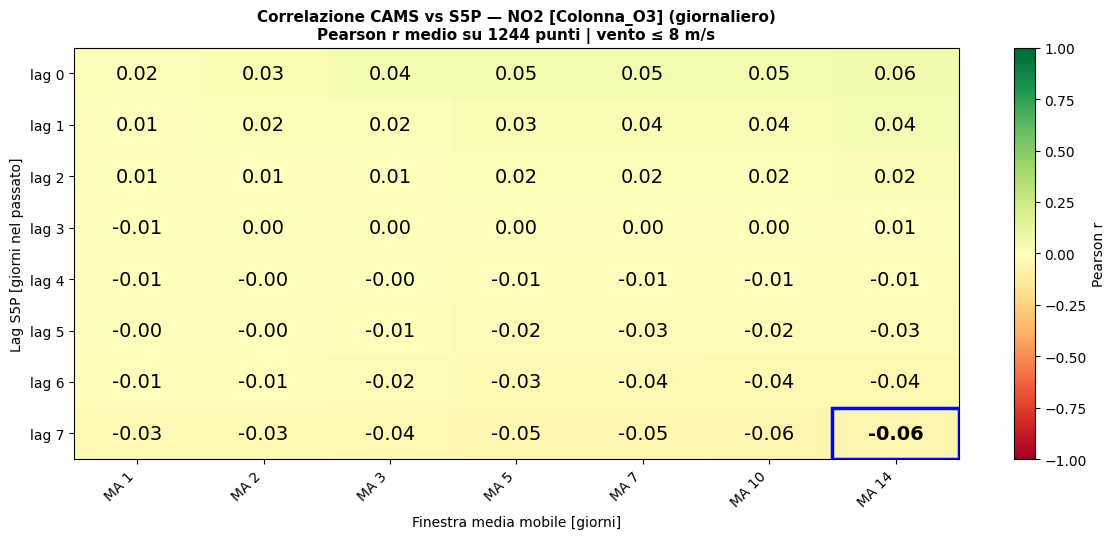

  Aerosol_Index  → ottimale: lag=7, MA=14 | r=+0.6227 (±0.292, 1244 punti)


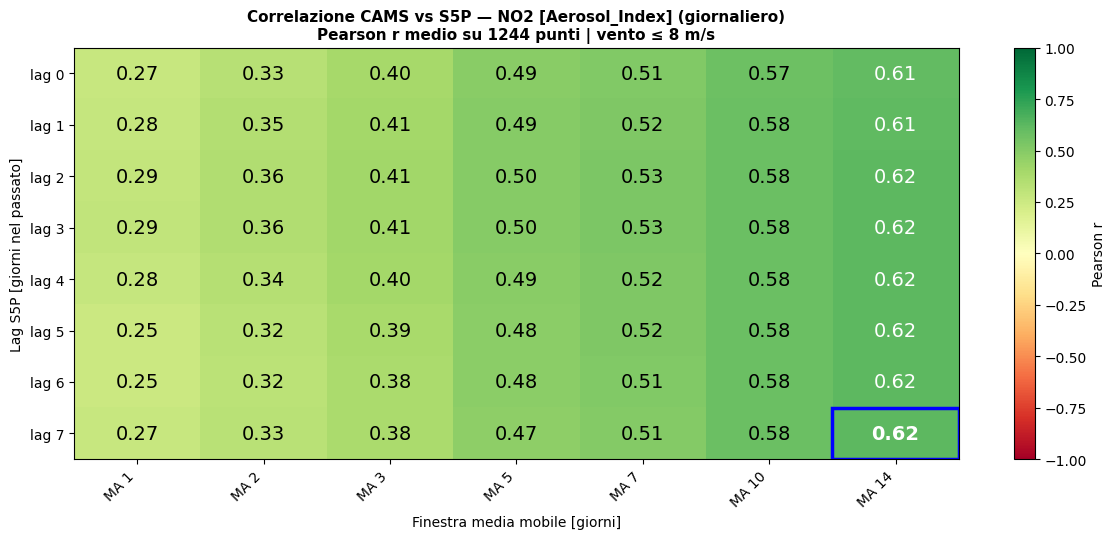

  SO2_proxy      → ottimale: lag=1, MA=14 | r=+0.2064 (±0.240, 1244 punti)


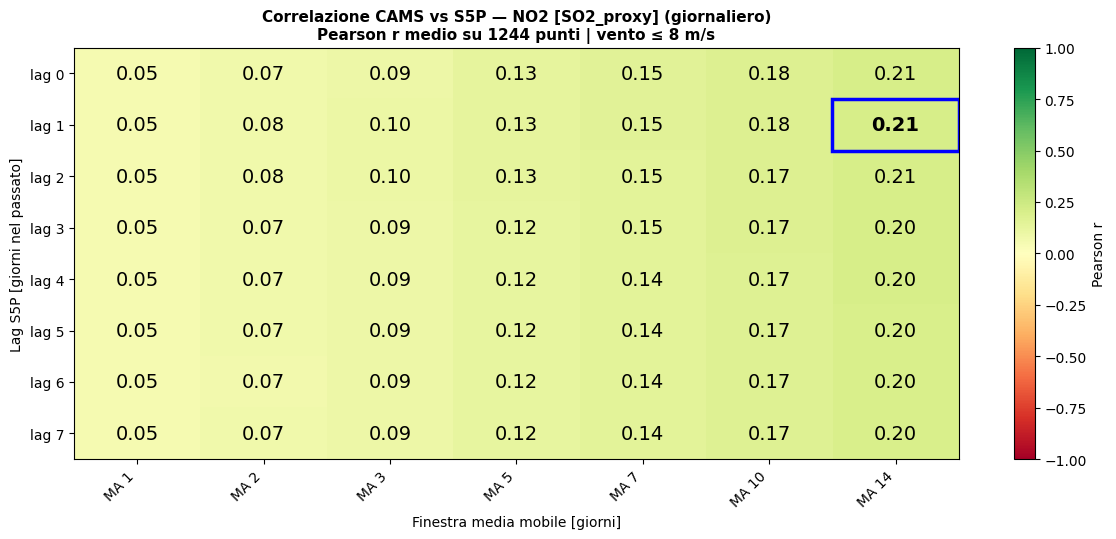

  HCHO_proxy     → ottimale: lag=0, MA=14 | r=-0.4931 (±0.122, 1244 punti)


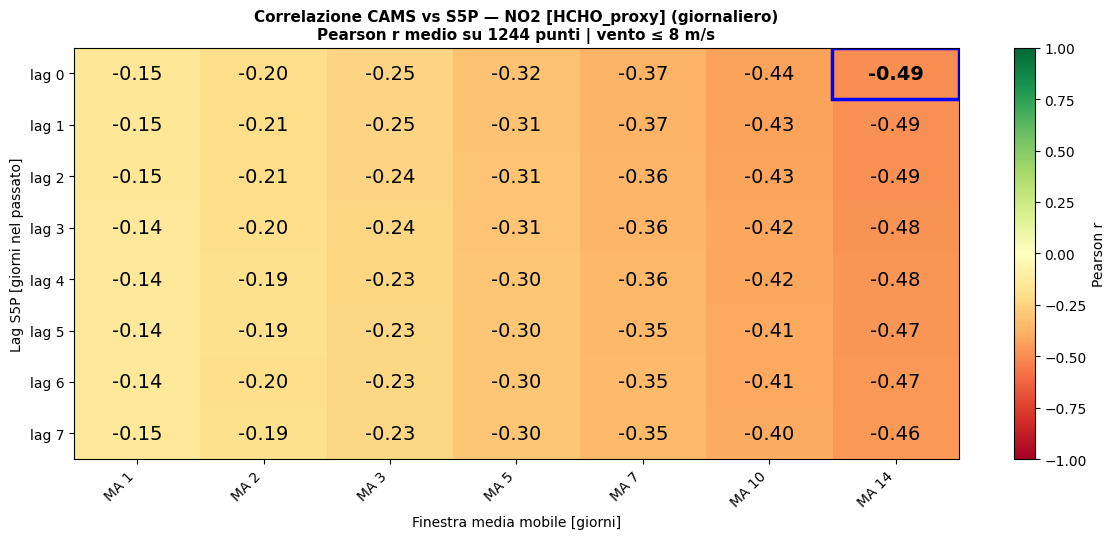


  O3 — Colonna totale O3; NO2 e HCHO come precursori fotochimici
  Colonna_O3     → ottimale: lag=7, MA=14 | r=+0.3237 (±0.106, 1244 punti)


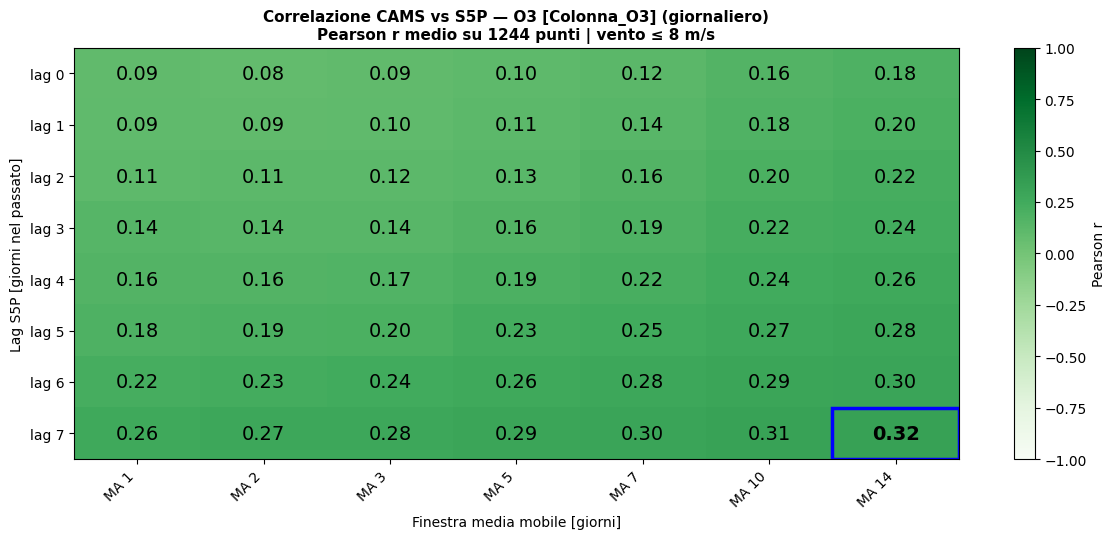

  NO2_proxy      → ottimale: lag=0, MA=14 | r=-0.8080 (±0.097, 1244 punti)


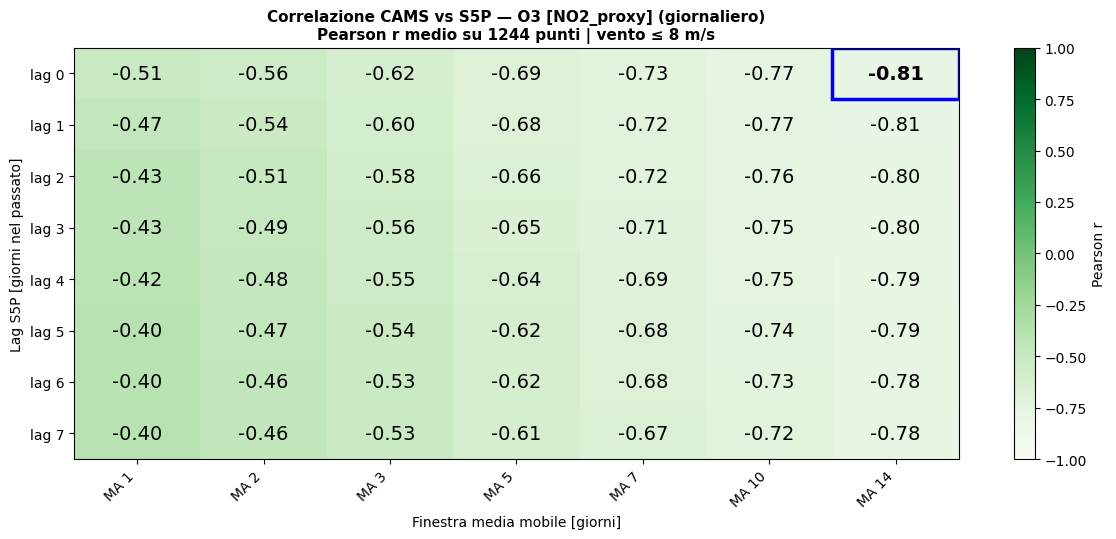

  HCHO_proxy     → ottimale: lag=0, MA=14 | r=+0.4741 (±0.159, 1244 punti)


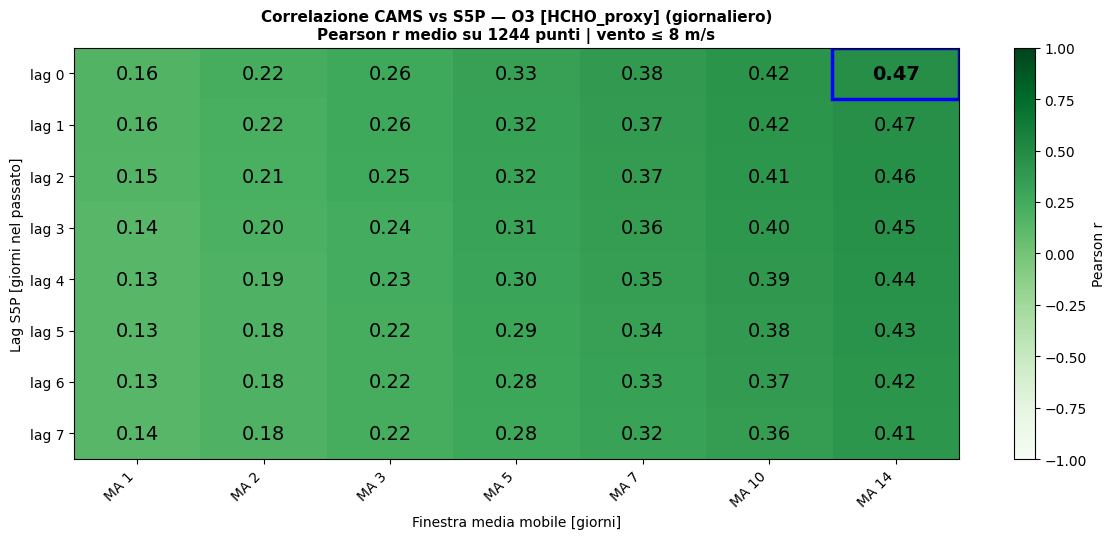


  PM10 — Test multipli proxy per PM10 (con SO2 e HCHO)
  Aerosol_Index  → ottimale: lag=3, MA=14 | r=+0.5110 (±0.256, 1244 punti)


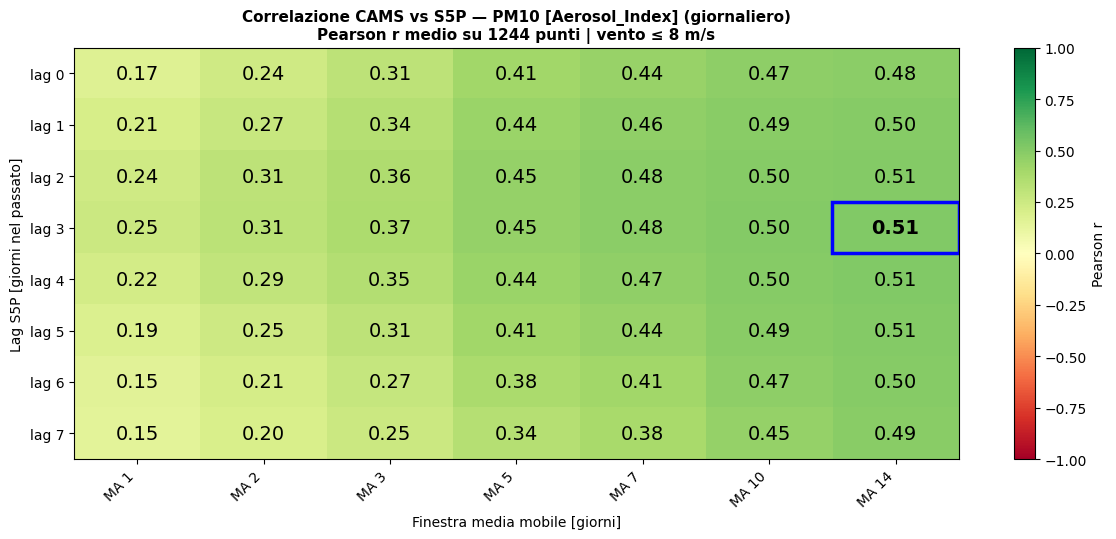

  NO2_proxy      → ottimale: lag=0, MA=14 | r=+0.5049 (±0.406, 1244 punti)


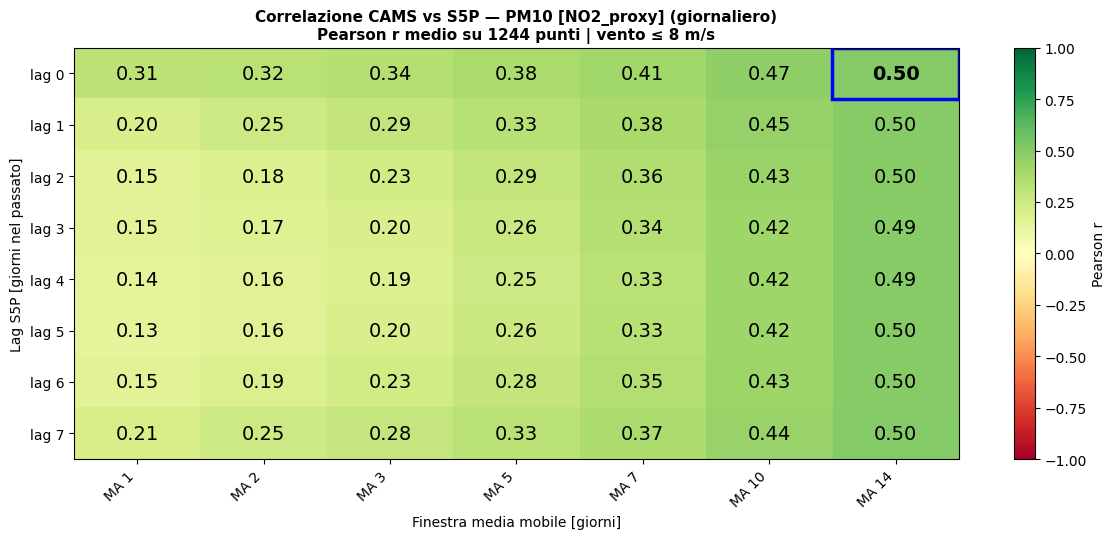

  SO2_proxy      → ottimale: lag=0, MA=14 | r=+0.1485 (±0.237, 1244 punti)


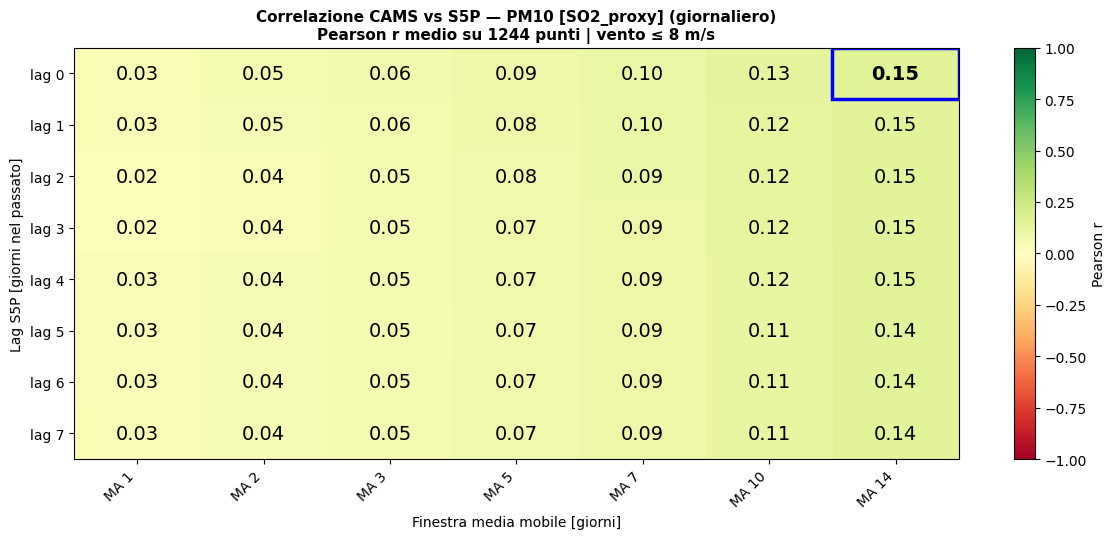

  HCHO_proxy     → ottimale: lag=7, MA=14 | r=-0.3340 (±0.182, 1244 punti)


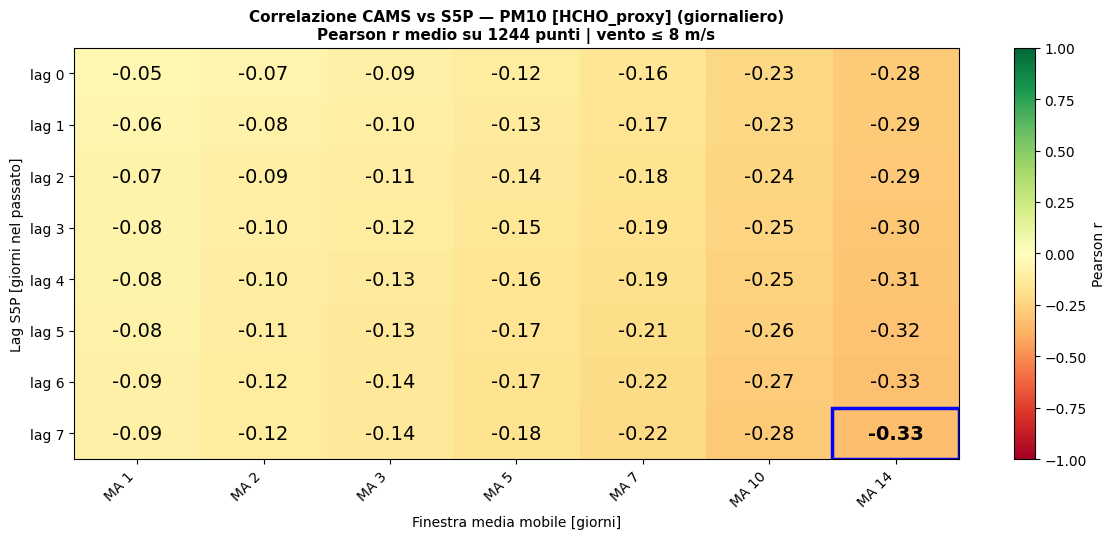


  PM25 — Test multipli proxy per PM2.5 (con SO2 e HCHO)
  Aerosol_Index  → ottimale: lag=4, MA=14 | r=+0.5064 (±0.251, 1244 punti)


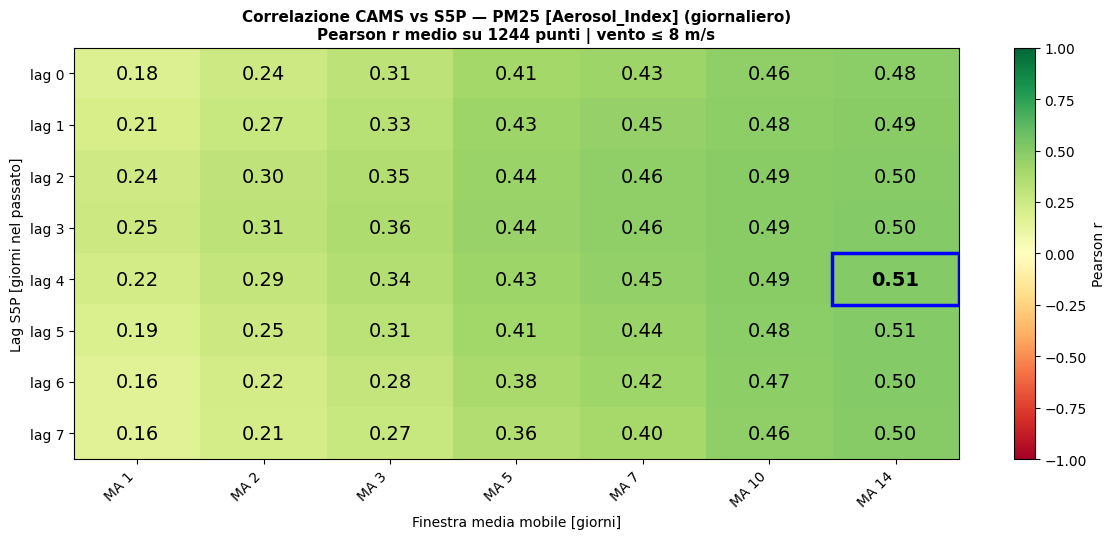

  NO2_proxy      → ottimale: lag=7, MA=14 | r=+0.5538 (±0.385, 1244 punti)


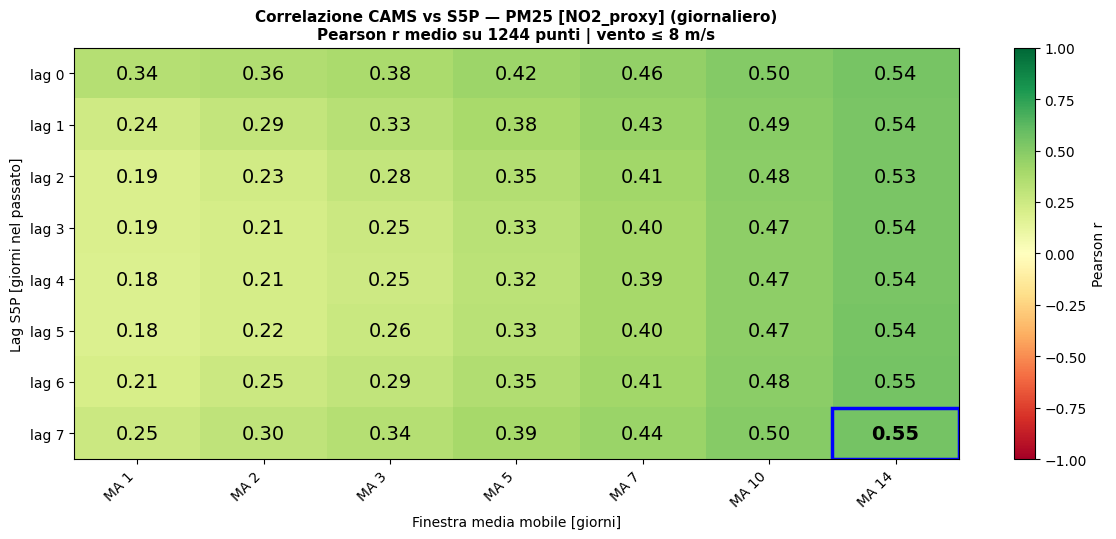

  SO2_proxy      → ottimale: lag=0, MA=14 | r=+0.1636 (±0.249, 1244 punti)


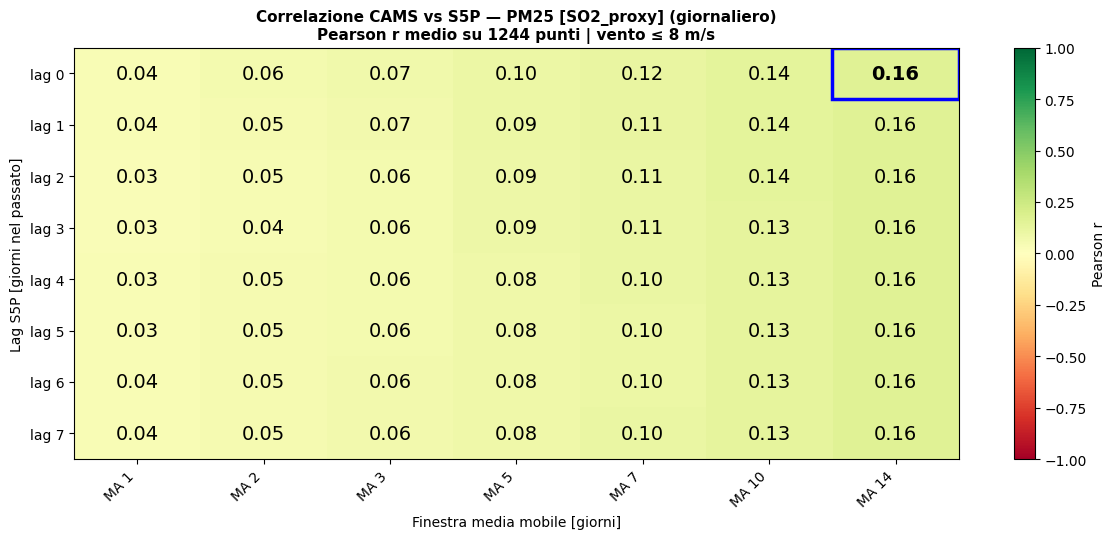

  HCHO_proxy     → ottimale: lag=7, MA=14 | r=-0.3860 (±0.162, 1244 punti)


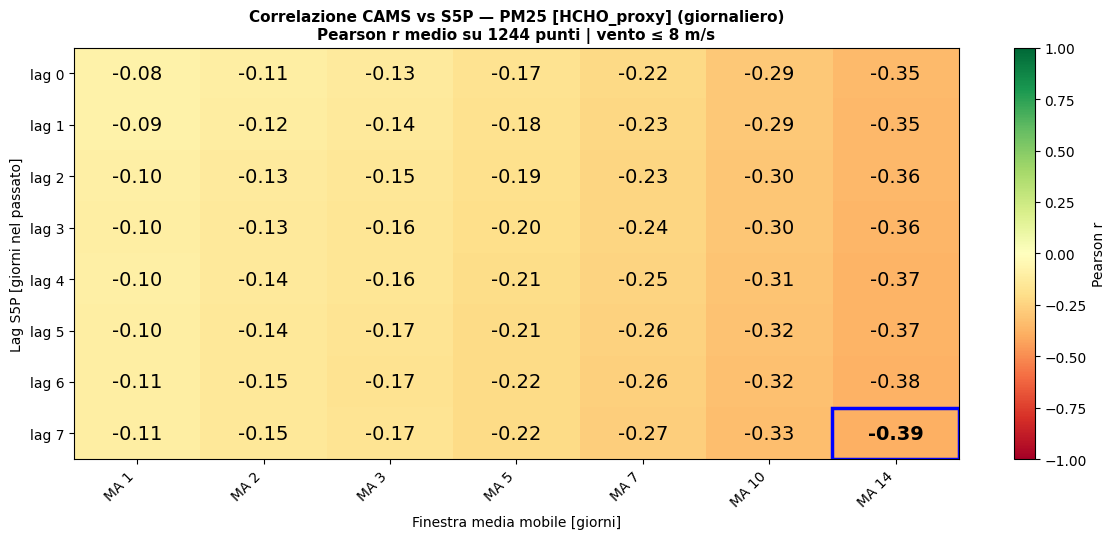

In [13]:
risultati_g, riepilogo_g, cache_g = esegui_analisi(
    df_g, VARIABILI, LAG_STEPS, MA_WINDOWS, 'giornaliero')

### 5.1 Allineamento temporale target ↔ Sentinel-5

Convenzione dei lag: **lag = L** significa confrontare il **target CAMS del giorno *t*** con il **predittore Sentinel-5 del giorno *t − L***. Il target resta fermo; lo `shift(L)` è applicato esclusivamente ai predittori Sentinel-5. La media mobile è **retrospettiva**: la finestra MA di ampiezza *W* copre l'intervallo *[t − L − (W−1), t − L]* e non usa mai giorni futuri.

La tabella seguente esplicita, per ogni inquinante e alla sua combinazione (lag, MA) ottimale, la **data target CAMS**, la **data o l'intervallo Sentinel-5**, il **lag** e la **finestra** applicata.

In [14]:
# ── Tabella di allineamento temporale target CAMS ↔ predittore Sentinel-5 ─────
# Alla combinazione (lag, MA) ottimale, il target CAMS del giorno t e' confrontato
# con il Sentinel-5 del giorno t-lag, mediato retrospettivamente sulla finestra MA:
# intervallo [t-lag-(MA-1), t-lag].
from IPython.display import Markdown, display

_data_target_esempio = pd.Timestamp(df_g['data'].max()).normalize()

righe_align = []
for _, r in riepilogo_g.iterrows():
    lag = int(r['lag_ottimale'])
    ma  = int(r['ma_ottimale'])
    t   = _data_target_esempio
    s5p_fine   = t - pd.Timedelta(days=lag)             # giorno S5P (fine finestra MA)
    s5p_inizio = s5p_fine - pd.Timedelta(days=ma - 1)   # inizio finestra MA
    if ma <= 1:
        intervallo = s5p_fine.date().isoformat()
    else:
        intervallo = f"{s5p_inizio.date().isoformat()} → {s5p_fine.date().isoformat()}"
    righe_align.append({
        'Inquinante': r['variabile'],
        'Proxy S5P': r['proxy_ottimale'],
        'Data target CAMS (t)': t.date().isoformat(),
        'Lag [giorni]': lag,
        'Finestra MA [giorni]': ma,
        'Data/intervallo Sentinel-5': intervallo,
    })

tab_align = pd.DataFrame(righe_align)
tab_align.to_csv(OUTPUT_DIR / 'allineamento_temporale_giornaliero.csv',
                 sep=';', decimal=',', index=False)

display(Markdown(
    f"**Esempio di allineamento** con data target *t* = {_data_target_esempio.date().isoformat()} "
    "(ultima data disponibile). Per ogni inquinante il target CAMS del giorno *t* e' confrontato con "
    "il Sentinel-5 del giorno *t − lag*; con finestra MA > 1 il valore S5P e' la media retrospettiva "
    "sull'intervallo indicato (nessun giorno futuro)."
))
display(tab_align)

**Esempio di allineamento** con data target *t* = 2025-12-31 (ultima data disponibile). Per ogni inquinante il target CAMS del giorno *t* e' confrontato con il Sentinel-5 del giorno *t − lag*; con finestra MA > 1 il valore S5P e' la media retrospettiva sull'intervallo indicato (nessun giorno futuro).

,Inquinante,Proxy S5P,Data target CAMS (t),Lag [giorni],Finestra MA [giorni],Data/intervallo Sentinel-5
0,NO2,NO2_TROPOMI,2025-12-31,7,14,2025-12-11 → 2025-12-24
1,O3,NO2_proxy,2025-12-31,0,14,2025-12-18 → 2025-12-31
2,PM10,Aerosol_Index,2025-12-31,3,14,2025-12-15 → 2025-12-28
3,PM25,NO2_proxy,2025-12-31,7,14,2025-12-11 → 2025-12-24


## 6. Analisi per settore di vento

Per ogni inquinante, alla combinazione lag/MA ottimale del proxy migliore, l'r medio viene ricalcolato separando le osservazioni per settore di provenienza del vento. Differenze marcate tra settori indicano l'influenza del trasporto degli inquinanti (es. sorgenti localizzate sopravento).

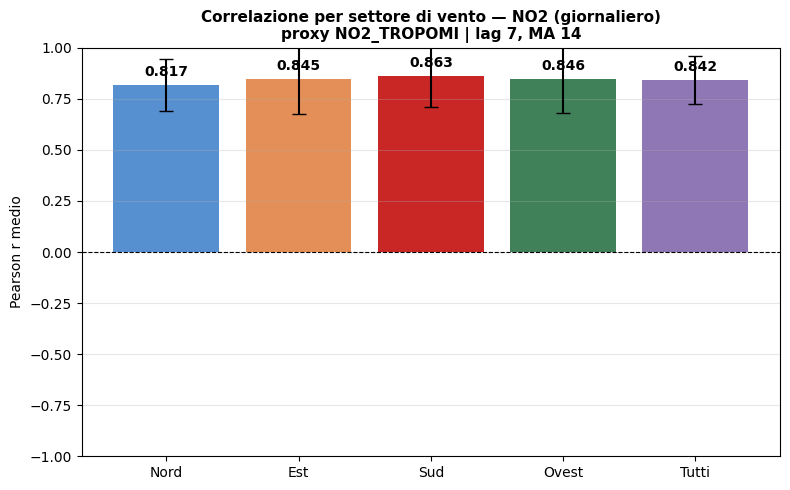

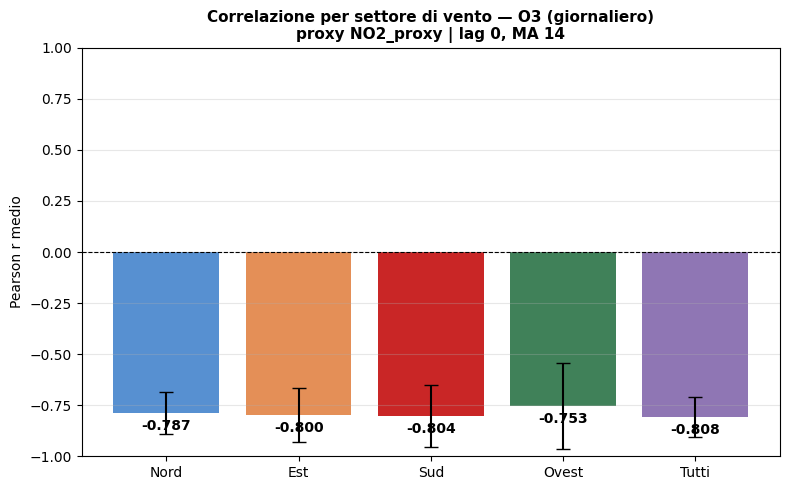

OSError: [Errno 22] Invalid argument: 'risultati_correlazione\\settori_giornaliero_PM10.png'

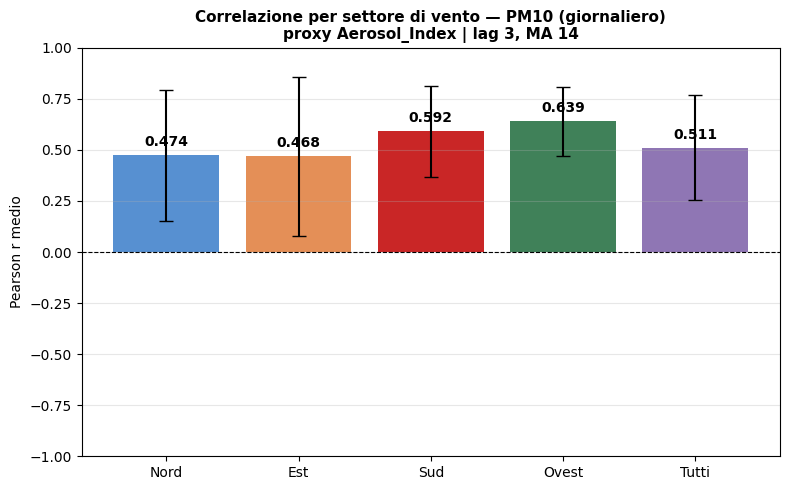

In [16]:
def plot_settori(df_settori, var_label, riga_riep, etichetta):
    fig, ax = plt.subplots(figsize=(8, 5))
    settori = df_settori['settore'].tolist()
    r_vals = df_settori['r_medio'].tolist()
    r_std = df_settori['r_std'].tolist()
    bars = ax.bar(settori, r_vals,
                  color=[COLORI_SETTORI.get(s, '#888888') for s in settori],
                  alpha=0.85, yerr=r_std, capsize=5, error_kw={'linewidth': 1.5})
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_ylim(-1, 1)
    ax.set_ylabel('Pearson r medio')
    ax.set_title(f"Correlazione per settore di vento — {var_label} ({etichetta})\n"
                 f"proxy {riga_riep['proxy_ottimale']} | lag {riga_riep['lag_ottimale']}, "
                 f"MA {riga_riep['ma_ottimale']}", fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, r_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.03 * np.sign(val),
                f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top',
                fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"settori_{etichetta}_{var_label}.png",
                dpi=150, bbox_inches='tight')
    plt.show()


settori_g = {}
for _, riga in riepilogo_g.iterrows():
    cfg = VARIABILI[riga['variabile']]
    df_sett = analisi_per_settore(df_g, cfg['cams_col'], riga['s5p_col'],
                                  riga['lag_ottimale'], riga['ma_ottimale'], cache_g)
    settori_g[riga['variabile']] = df_sett
    df_sett.to_csv(OUTPUT_DIR / f"settori_giornaliero_{riga['variabile']}.csv",
                   sep=';', decimal=',', index=False)
    plot_settori(df_sett, riga['variabile'], riga, 'giornaliero')

## 7. Confronto tra proxy S5P

Per O₃, PM10 e PM2.5 sono stati testati più proxy satellitari: il grafico confronta l'r ottimale (alla migliore combinazione lag/MA) di ciascun proxy, per identificare quale misura Sentinel-5P è maggiormente correlata all'inquinante CAMS.

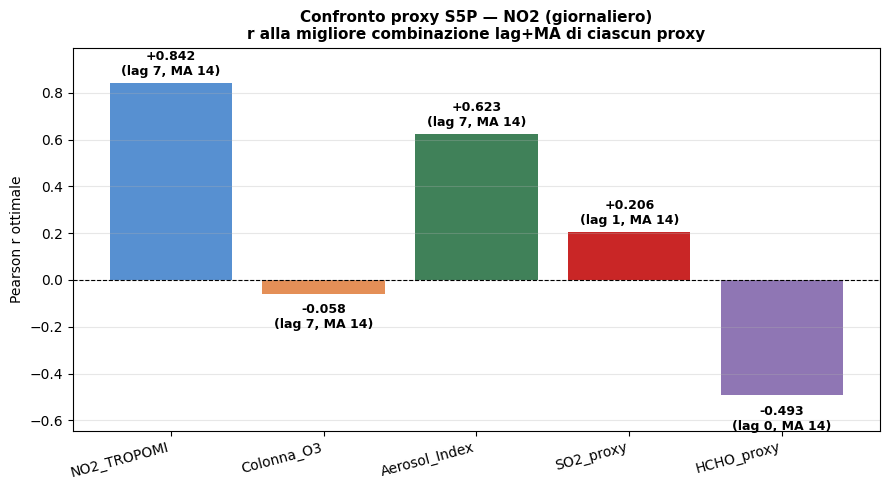

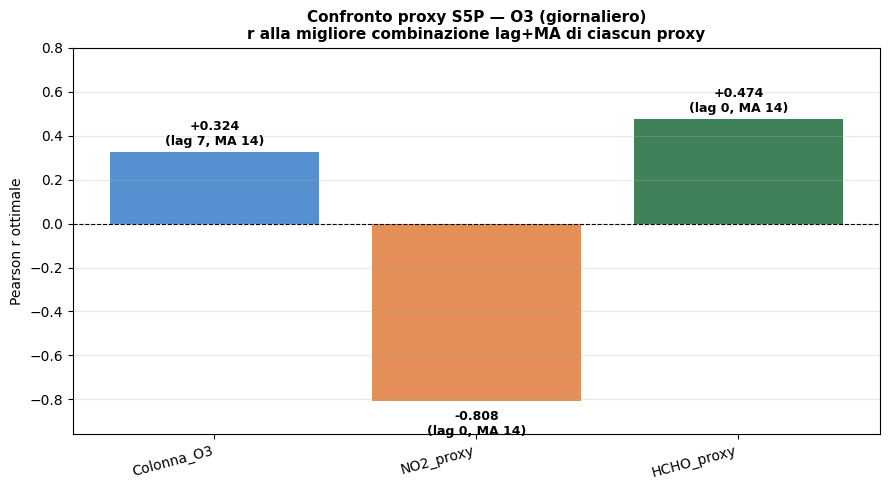

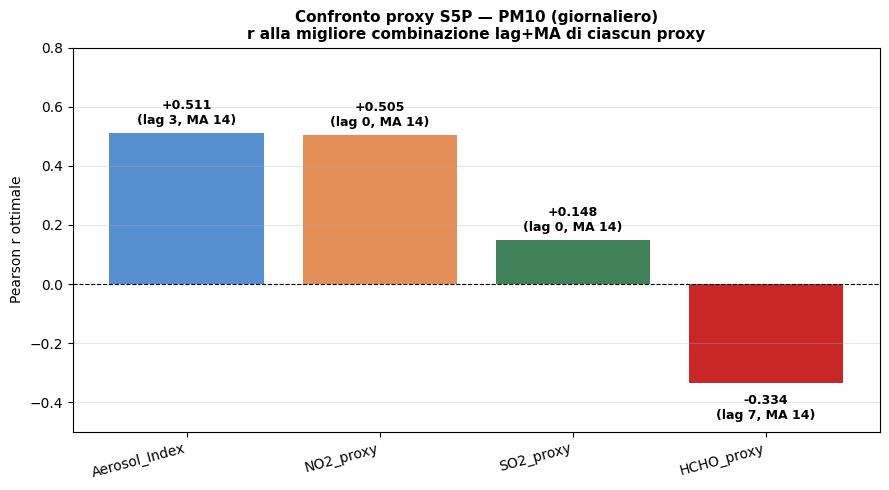

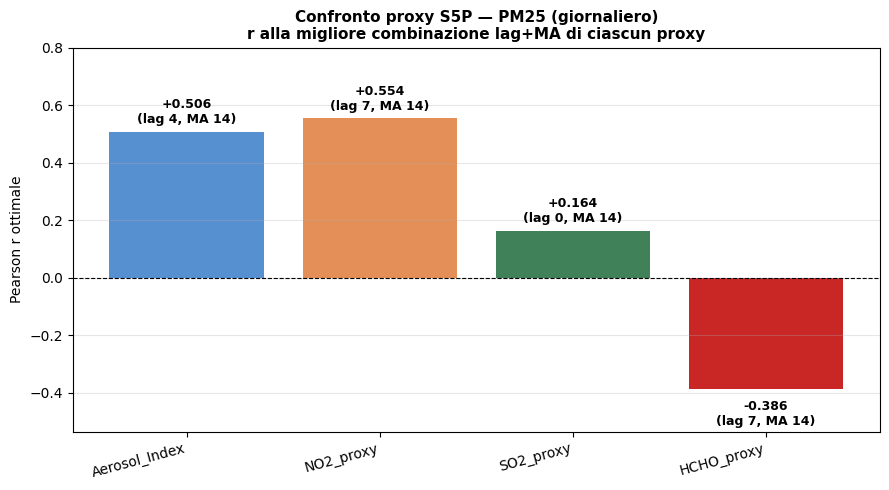

In [17]:
def plot_confronto_proxy(df_proxy, var_label, etichetta):
    colori_proxy = ['#3A7DC9', '#E07B39', '#1E6B3C', '#C00000', '#7B5EA7']
    fig, ax = plt.subplots(figsize=(9, 5))
    proxies = df_proxy['proxy_s5p'].tolist()
    r_vals = df_proxy['r_ottimale'].tolist()
    dettagli = [f"lag {l}, MA {m}" for l, m in zip(df_proxy['lag'], df_proxy['ma'])]
    bars = ax.bar(proxies, r_vals, color=colori_proxy[:len(proxies)], alpha=0.85)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_ylim(min(-0.5, min(r_vals) - 0.15), max(0.8, max(r_vals) + 0.15))
    ax.set_ylabel('Pearson r ottimale')
    ax.set_title(f"Confronto proxy S5P — {var_label} ({etichetta})\n"
                 f"r alla migliore combinazione lag+MA di ciascun proxy",
                 fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=15, ha='right')
    for bar, val, det in zip(bars, r_vals, dettagli):
        ax.text(bar.get_x() + bar.get_width() / 2,
                val + (0.02 if val >= 0 else -0.04),
                f'{val:+.3f}\n({det})', ha='center',
                va='bottom' if val >= 0 else 'top', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"proxy_confronto_{etichetta}_{var_label}.png",
                dpi=150, bbox_inches='tight')
    plt.show()


for var_label in VARIABILI:
    chiave = (var_label, '_confronto_proxy')
    if chiave in risultati_g and len(risultati_g[chiave]) > 1:
        plot_confronto_proxy(risultati_g[chiave], var_label, 'giornaliero')

## 8. Analisi di dispersione e best fitting

Per ogni inquinante, scatter plot **CAMS (con lag e MA ottimali) vs proxy S5P migliore**, con:
- **fit lineare** (minimi quadrati): equazione, r, R², p-value;
- **fit polinomiale di 2° grado**: equazione e R², per verificare se una curvatura migliora l'adattamento.

> Nota: qui la regressione è calcolata sull'insieme di **tutti i punti insieme** (pooled), quindi l'r può differire leggermente dall'r *medio per punto* riportato nelle matrici — il confronto tra i due valori indica quanta parte della correlazione deriva dalla variabilità spaziale tra punti rispetto alla dinamica temporale.

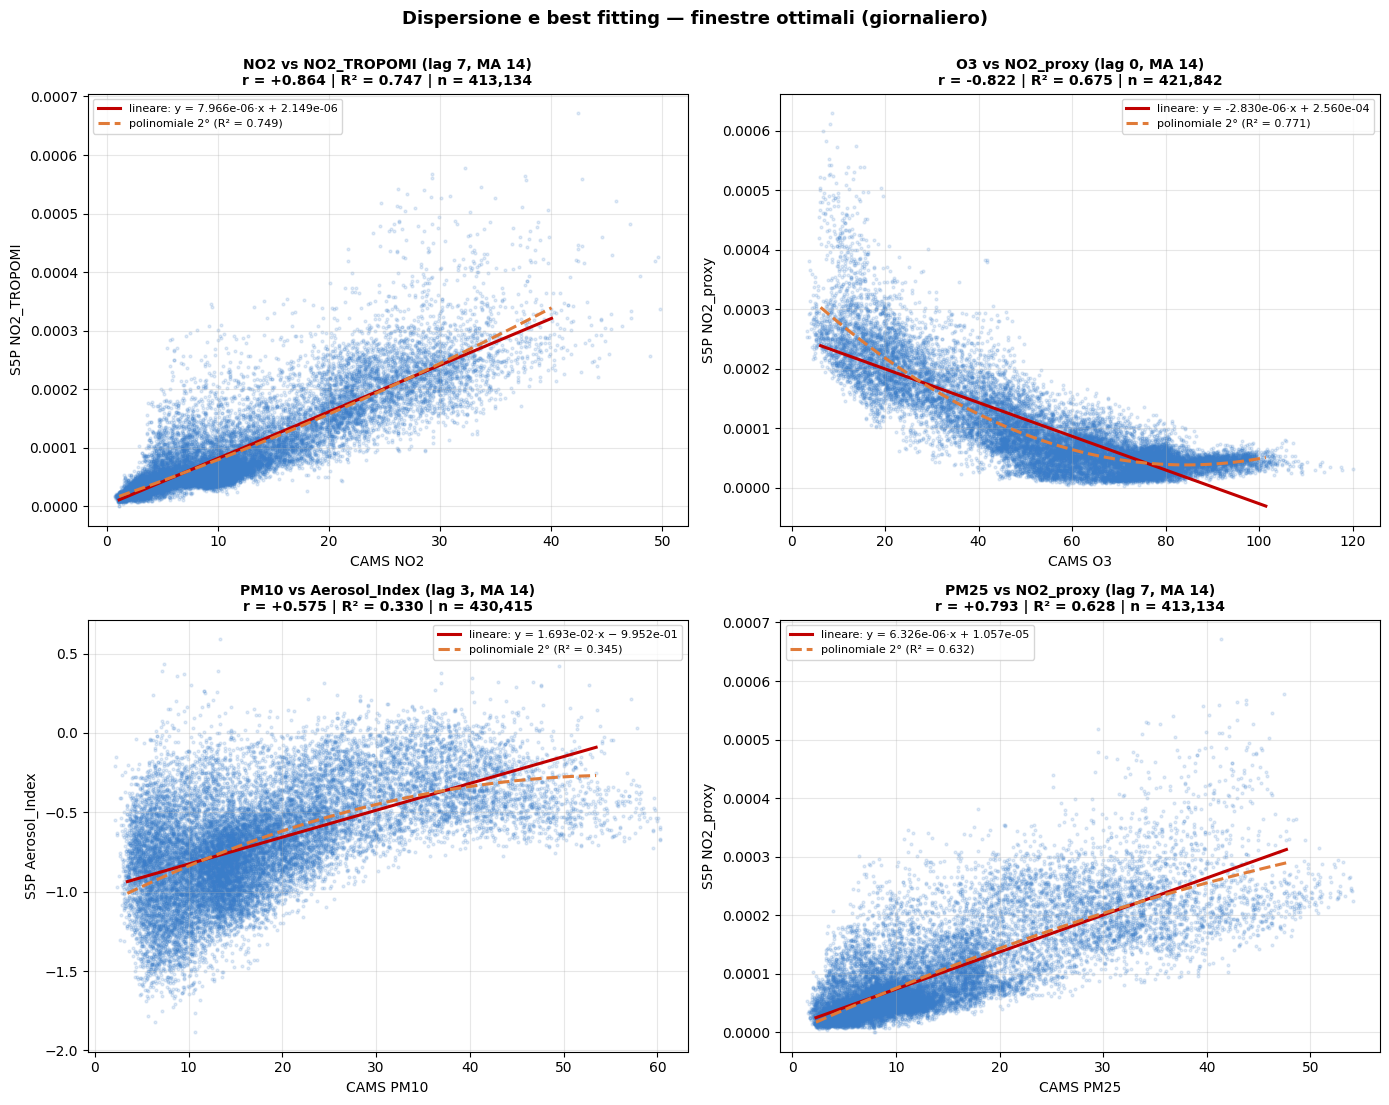

,variabile,proxy,lag,ma,slope,intercept,r_pooled,R2,a2,a1,a0,R2_poly,p_value,n
0,NO2,NO2_TROPOMI,7,14,0.000008,0.000002,0.864027,0.746543,4.160486e-08,0.000007,9.722623e-06,0.748766,0.0,413134
1,O3,NO2_proxy,0,14,-0.000003,0.000256,-0.821501,0.674864,4.330308e-08,-0.000007,3.466522e-04,0.770940,0.0,421842
2,PM10,Aerosol_Index,3,14,0.016928,-0.995241,0.574653,0.330226,-2.666632e-04,0.030042,-1.112140e+00,0.345007,0.0,430415
3,PM25,NO2_proxy,7,14,0.000006,0.000011,0.792555,0.628144,-4.042314e-08,0.000008,-8.148410e-07,0.631763,0.0,413134


In [18]:
def scatter_best_fit(df, riepilogo, variabili, cache, etichetta):
    vento_ok = ~(df['vento_velocita'] > SOGLIA_VENTO_MS)
    punto = df['punto_id']
    n_var = len(riepilogo)
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    axes = axes.ravel()
    fit_righe = []

    for ax, (_, riga) in zip(axes, riepilogo.iterrows()):
        cfg = variabili[riga['variabile']]
        # target CAMS(t) fermo sull'asse x; predittore S5P spostato di lag sull'asse y
        x = media_mobile(df, cfg['cams_col'], riga['ma_ottimale'], cache).where(vento_ok)
        y = applica_lag(media_mobile(df, riga['s5p_col'], riga['ma_ottimale'], cache),
                        punto, riga['lag_ottimale']).where(vento_ok)
        validi = x.notna() & y.notna()
        xv, yv = x[validi].values, y[validi].values

        fit = stats.linregress(xv, yv)
        coef2 = np.polyfit(xv, yv, 2)          # fit polinomiale di 2° grado
        ss_tot = np.sum((yv - yv.mean()) ** 2)
        r2_poly = 1 - np.sum((yv - np.polyval(coef2, xv)) ** 2) / ss_tot
        fit_righe.append({'variabile': riga['variabile'],
                          'proxy': riga['proxy_ottimale'],
                          'lag': riga['lag_ottimale'], 'ma': riga['ma_ottimale'],
                          'slope': fit.slope, 'intercept': fit.intercept,
                          'r_pooled': fit.rvalue, 'R2': fit.rvalue ** 2,
                          'a2': coef2[0], 'a1': coef2[1], 'a0': coef2[2],
                          'R2_poly': r2_poly,
                          'p_value': fit.pvalue, 'n': len(xv)})

        # sottocampionamento solo per la visualizzazione
        if len(xv) > 20000:
            idx = np.random.default_rng(42).choice(len(xv), 20000, replace=False)
            xp, yp = xv[idx], yv[idx]
        else:
            xp, yp = xv, yv
        ax.scatter(xp, yp, s=4, alpha=0.15, color='#3A7DC9', rasterized=True)

        xr = np.linspace(np.nanpercentile(xv, 0.5), np.nanpercentile(xv, 99.5), 100)
        ax.plot(xr, fit.intercept + fit.slope * xr, color='#C00000', lw=2.2,
                label=f"lineare: y = {fit.slope:.3e}·x {'+' if fit.intercept >= 0 else '−'} "
                      f"{abs(fit.intercept):.3e}")
        ax.plot(xr, np.polyval(coef2, xr), color='#E07B39', lw=2.2, ls='--',
                label=f"polinomiale 2° (R² = {r2_poly:.3f})")
        ax.set_title(f"{riga['variabile']} vs {riga['proxy_ottimale']} "
                     f"(lag {riga['lag_ottimale']}, MA {riga['ma_ottimale']})\n"
                     f"r = {fit.rvalue:+.3f} | R² = {fit.rvalue ** 2:.3f} | "
                     f"n = {len(xv):,}",
                     fontsize=10, fontweight='bold')
        ax.set_xlabel(f"CAMS {riga['variabile']}")
        ax.set_ylabel(f"S5P {riga['proxy_ottimale']}")
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3)

    for ax in axes[n_var:]:
        ax.set_visible(False)
    fig.suptitle(f"Dispersione e best fitting — finestre ottimali ({etichetta})",
                 fontsize=13, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"dispersione_bestfit_{etichetta}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    return pd.DataFrame(fit_righe)


df_fit_g = scatter_best_fit(df_g, riepilogo_g, VARIABILI, cache_g, 'giornaliero')
df_fit_g.to_csv(OUTPUT_DIR / 'bestfit_giornaliero.csv', sep=';', decimal=',', index=False)
df_fit_g

### Tabella riassuntiva del best fitting

Per ogni inquinante: configurazione ottimale (lag, MA, proxy S5P) ed equazioni dei fit **lineare** (con r e R²) e **polinomiale di 2° grado** (con R²). La tabella viene salvata anche come CSV e PNG in `risultati_correlazione/`.

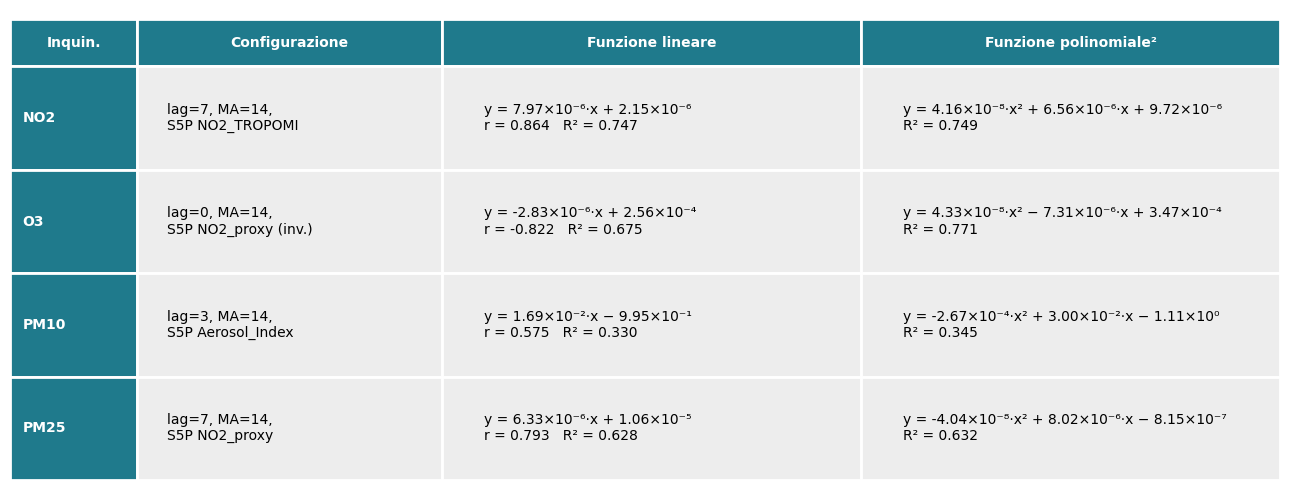

Inquin.,Configurazione,Funzione lineare,Funzione polinomiale²
NO2,"lag=7, MA=14, S5P NO2_TROPOMI",y = 7.97×10⁻⁶·x + 2.15×10⁻⁶ r = 0.864 R² = 0.747,y = 4.16×10⁻⁸·x² + 6.56×10⁻⁶·x + 9.72×10⁻⁶ R² = 0.749
O3,"lag=0, MA=14, S5P NO2_proxy (inv.)",y = -2.83×10⁻⁶·x + 2.56×10⁻⁴ r = -0.822 R² = 0.675,y = 4.33×10⁻⁸·x² − 7.31×10⁻⁶·x + 3.47×10⁻⁴ R² = 0.771
PM10,"lag=3, MA=14, S5P Aerosol_Index",y = 1.69×10⁻²·x − 9.95×10⁻¹ r = 0.575 R² = 0.330,y = -2.67×10⁻⁴·x² + 3.00×10⁻²·x − 1.11×10⁰ R² = 0.345
PM25,"lag=7, MA=14, S5P NO2_proxy",y = 6.33×10⁻⁶·x + 1.06×10⁻⁵ r = 0.793 R² = 0.628,y = -4.04×10⁻⁸·x² + 8.02×10⁻⁶·x − 8.15×10⁻⁷ R² = 0.632


In [19]:
# ── Utilità di formattazione e stile per le tabelle ──────────────────────────
APICI = str.maketrans('-0123456789', '⁻⁰¹²³⁴⁵⁶⁷⁸⁹')

def formatta_sci(v, dec=2):
    # notazione scientifica compatta, es. 6.32×10⁻¹
    if not np.isfinite(v) or v == 0:
        return '0'
    esp = int(np.floor(np.log10(abs(v))))
    mant = v / 10.0 ** esp
    return f"{mant:.{dec}f}×10{str(esp).translate(APICI)}"

def segno(v):
    return '+' if v >= 0 else '−'

STILE_TABELLA = [
    {'selector': 'th.col_heading',
     'props': [('background-color', '#1F7A8C'), ('color', 'white'),
               ('font-weight', 'bold'), ('text-align', 'center'),
               ('padding', '8px 14px'), ('border', '2px solid white')]},
    {'selector': 'td',
     'props': [('background-color', '#EDEDED'), ('color', '#222222'),
               ('white-space', 'pre-wrap'), ('padding', '8px 14px'),
               ('border', '2px solid white'), ('font-size', '13px'),
               ('text-align', 'left'), ('vertical-align', 'middle')]},
]

def stile_prima_colonna(col):
    return ['background-color: #1F7A8C; color: white; font-weight: bold'] * len(col)

def tabella_png(tab, nome_file, larghezze_col, altezza_riga=0.22):
    # esporta la tabella come immagine PNG (stessa palette dello stile HTML)
    n_r = len(tab)
    fig, ax = plt.subplots(figsize=(13, 1.0 + 1.0 * n_r))
    ax.axis('off')
    t = ax.table(cellText=tab.astype(str).values.tolist(),
                 colLabels=list(tab.columns),
                 colWidths=larghezze_col, cellLoc='left', loc='upper center')
    t.auto_set_font_size(False)
    t.set_fontsize(10)
    for (i, j), cella in t.get_celld().items():
        cella.set_edgecolor('white')
        cella.set_linewidth(2)
        cella.set_height(0.10 if i == 0 else altezza_riga)
        testo = cella.get_text()
        if i == 0 or j == 0:
            cella.set_facecolor('#1F7A8C')
            testo.set_color('white')
            testo.set_fontweight('bold')
            if i == 0:
                testo.set_ha('center')
        else:
            cella.set_facecolor('#EDEDED')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / nome_file, dpi=180, bbox_inches='tight')
    plt.show()


# ── Tabella best fitting (come da layout richiesto) ──────────────────────────
righe_tab = []
for _, r in df_fit_g.iterrows():
    inverso = ' (inv.)' if r['r_pooled'] < 0 else ''
    lineare = (f"y = {formatta_sci(r['slope'])}·x {segno(r['intercept'])} "
               f"{formatta_sci(abs(r['intercept']))}\n"
               f"r = {r['r_pooled']:.3f}   R² = {r['R2']:.3f}")
    polinom = (f"y = {formatta_sci(r['a2'])}·x² {segno(r['a1'])} "
               f"{formatta_sci(abs(r['a1']))}·x {segno(r['a0'])} "
               f"{formatta_sci(abs(r['a0']))}\n"
               f"R² = {r['R2_poly']:.3f}")
    righe_tab.append({'Inquin.': r['variabile'],
                      'Configurazione': f"lag={r['lag']}, MA={r['ma']},\nS5P {r['proxy']}{inverso}",
                      'Funzione lineare': lineare,
                      'Funzione polinomiale²': polinom})

tab_fit = pd.DataFrame(righe_tab)
tab_fit.to_csv(OUTPUT_DIR / 'tabella_bestfit_giornaliero.csv',
               sep=';', decimal=',', index=False)
tabella_png(tab_fit, 'tabella_bestfit_giornaliero.png', [0.10, 0.24, 0.33, 0.33])

(tab_fit.style
    .set_table_styles(STILE_TABELLA)
    .apply(stile_prima_colonna, subset=['Inquin.'])
    .hide(axis='index'))

## 9. Riepilogo finale (dato giornaliero)

Per ogni inquinante: proxy S5P, lag e finestra di media mobile che massimizzano |r|, con deviazione standard tra i punti ed **esito** dell'analisi. La correlazione è considerata **esitosa se |r| ≥ 0.5** (correlazione da moderata a forte; per l'O₃ vale il valore assoluto, essendo la relazione con l'NO₂ inversa).

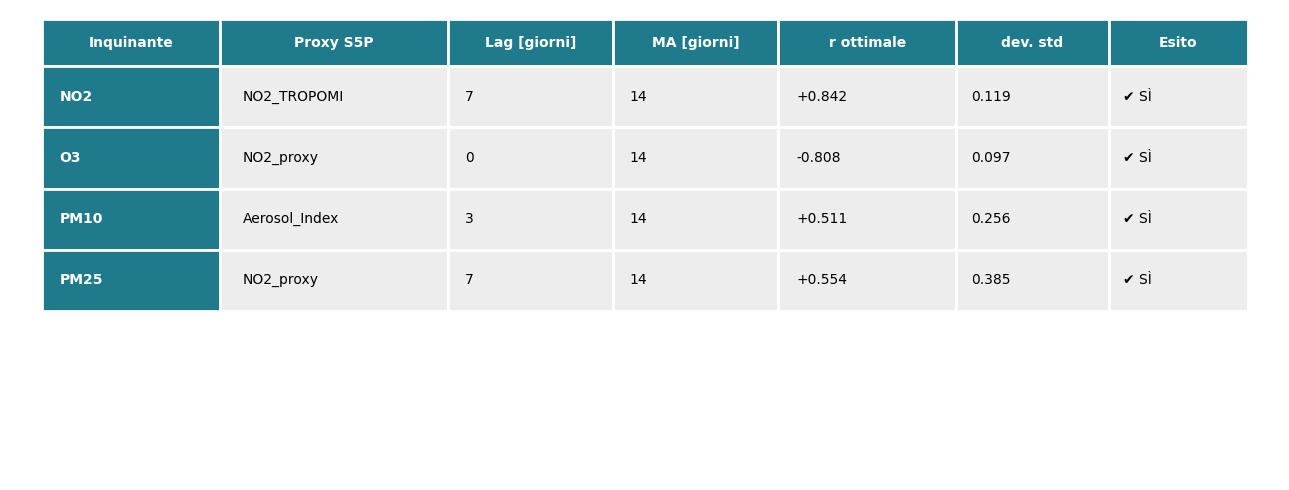

Inquinante,Proxy S5P,Lag [giorni],MA [giorni],r ottimale,dev. std,Esito
NO2,NO2_TROPOMI,7,14,+0.8420,0.1191,✔ SÌ
O3,NO2_proxy,0,14,-0.8080,0.0974,✔ SÌ
PM10,Aerosol_Index,3,14,+0.5110,0.2561,✔ SÌ
PM25,NO2_proxy,7,14,+0.5538,0.3847,✔ SÌ


In [20]:
SOGLIA_ESITO = 0.5   # |r| minimo per considerare la correlazione soddisfacente

tab_riep = riepilogo_g.copy()
tab_riep['esito'] = np.where(tab_riep['r_ottimale'].abs() >= SOGLIA_ESITO,
                             '✔ SÌ', '✘ NO')
tab_riep = tab_riep.rename(columns={
    'variabile': 'Inquinante', 'proxy_ottimale': 'Proxy S5P',
    'lag_ottimale': 'Lag [giorni]', 'ma_ottimale': 'MA [giorni]',
    'r_ottimale': 'r ottimale', 'r_std': 'dev. std', 'esito': 'Esito'
})[['Inquinante', 'Proxy S5P', 'Lag [giorni]', 'MA [giorni]',
    'r ottimale', 'dev. std', 'Esito']]

tab_riep.to_csv(OUTPUT_DIR / 'riepilogo_giornaliero.csv',
                sep=';', decimal=',', index=False)

# versione PNG
tab_riep_png = tab_riep.copy()
tab_riep_png['r ottimale'] = tab_riep_png['r ottimale'].map('{:+.3f}'.format)
tab_riep_png['dev. std'] = tab_riep_png['dev. std'].map('{:.3f}'.format)
tabella_png(tab_riep_png, 'tabella_riepilogo_giornaliero.png',
            [0.14, 0.18, 0.13, 0.13, 0.14, 0.12, 0.11], altezza_riga=0.13)

def colore_esito(col):
    return ['color: #1E6B3C; font-weight: bold' if str(v).startswith('✔')
            else 'color: #C00000; font-weight: bold' for v in col]

(tab_riep.style
    .set_table_styles(STILE_TABELLA)
    .apply(stile_prima_colonna, subset=['Inquinante'])
    .apply(colore_esito, subset=['Esito'])
    .format({'r ottimale': '{:+.4f}', 'dev. std': '{:.4f}'})
    .hide(axis='index'))

## 10. Confronto con il dato settimanale

La stessa pipeline viene applicata alle serie settimanali (`serie_temporali_settimanale.csv`), con lag 0–4 **settimane** e medie mobili fino a 4 settimane (~28 giorni). L'aggregazione settimanale riduce il rumore giornaliero (copertura nuvolosa, singoli passaggi satellitari) e in genere aumenta la correlazione.

In [21]:
LAG_STEPS_SETT = list(range(0, 5))   # 0–4 settimane nel passato
MA_WINDOWS_SETT = [1, 2, 3, 4]       # finestre da 1 a 4 settimane

risultati_s, riepilogo_s, cache_s = esegui_analisi(
    df_s, VARIABILI, LAG_STEPS_SETT, MA_WINDOWS_SETT, 'settimanale',
    mostra_grafici=False, unita='settimane')

riepilogo_s.to_csv(OUTPUT_DIR / 'riepilogo_settimanale.csv',
                   sep=';', decimal=',', index=False)


  NO2 — Misura diretta TROPOMI + confronto con altri indici S5P
  NO2_TROPOMI    → ottimale: lag=2, MA=4 | r=+0.9010 (±0.072, 1244 punti)
  Colonna_O3     → ottimale: lag=4, MA=3 | r=-0.3930 (±0.122, 1244 punti)
  Aerosol_Index  → ottimale: lag=2, MA=4 | r=+0.6766 (±0.344, 1244 punti)
  SO2_proxy      → ottimale: lag=1, MA=4 | r=+0.2697 (±0.326, 1244 punti)
  HCHO_proxy     → ottimale: lag=0, MA=4 | r=-0.5768 (±0.149, 1244 punti)

  O3 — Colonna totale O3; NO2 e HCHO come precursori fotochimici
  Colonna_O3     → ottimale: lag=4, MA=4 | r=+0.6548 (±0.084, 1244 punti)
  NO2_proxy      → ottimale: lag=0, MA=4 | r=-0.8499 (±0.082, 1244 punti)
  HCHO_proxy     → ottimale: lag=0, MA=4 | r=+0.5483 (±0.180, 1244 punti)

  PM10 — Test multipli proxy per PM10 (con SO2 e HCHO)
  Aerosol_Index  → ottimale: lag=1, MA=4 | r=+0.5295 (±0.329, 1244 punti)
  NO2_proxy      → ottimale: lag=4, MA=4 | r=+0.6499 (±0.280, 1244 punti)
  SO2_proxy      → ottimale: lag=1, MA=4 | r=+0.1940 (±0.324, 1244 punti)

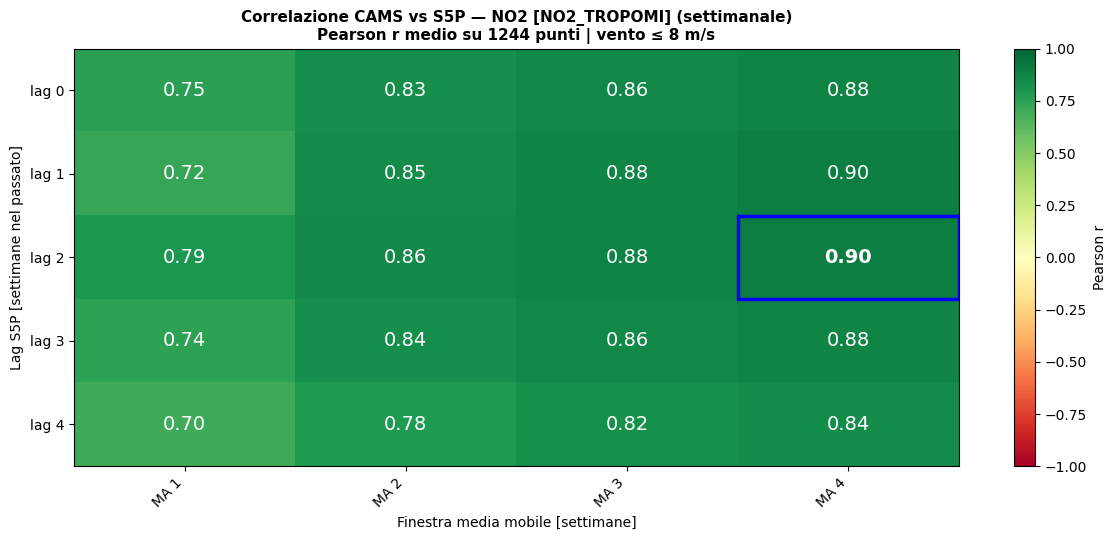

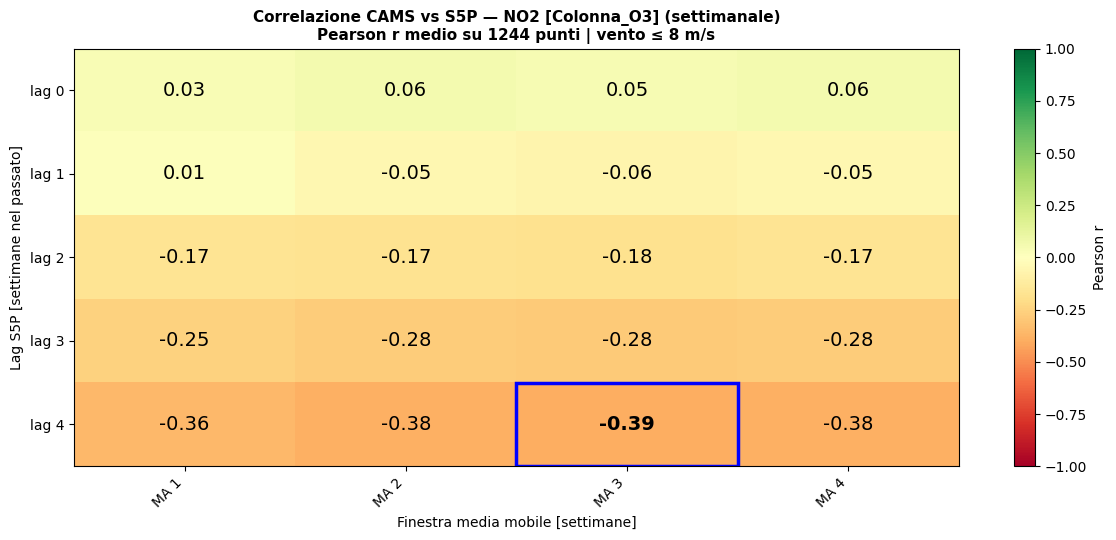

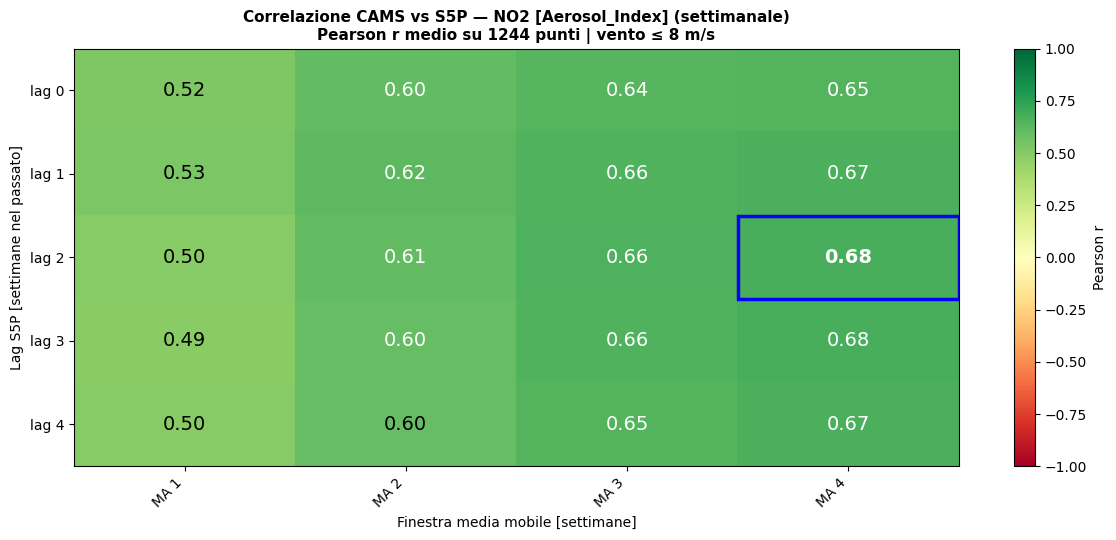

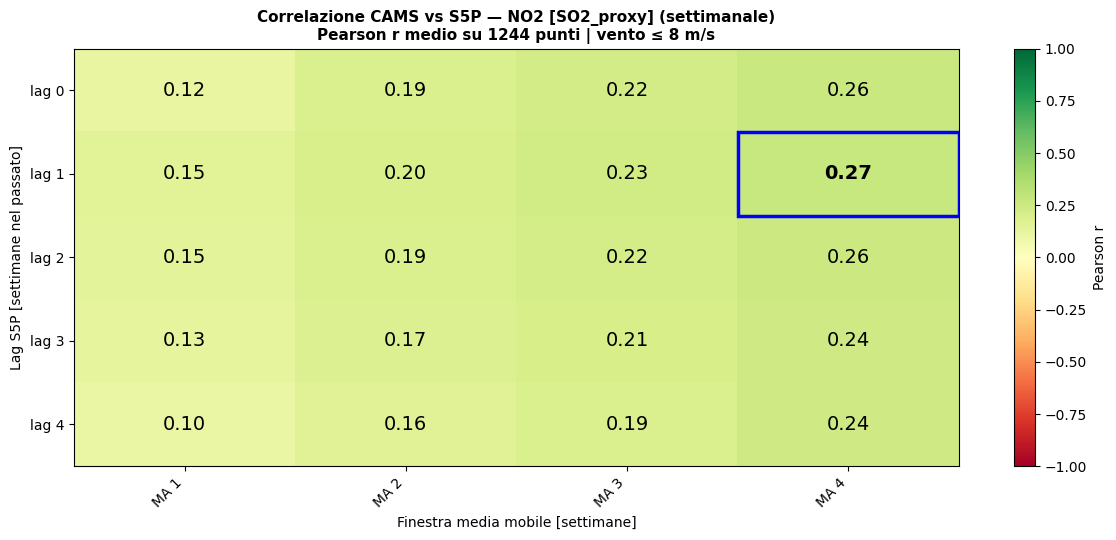

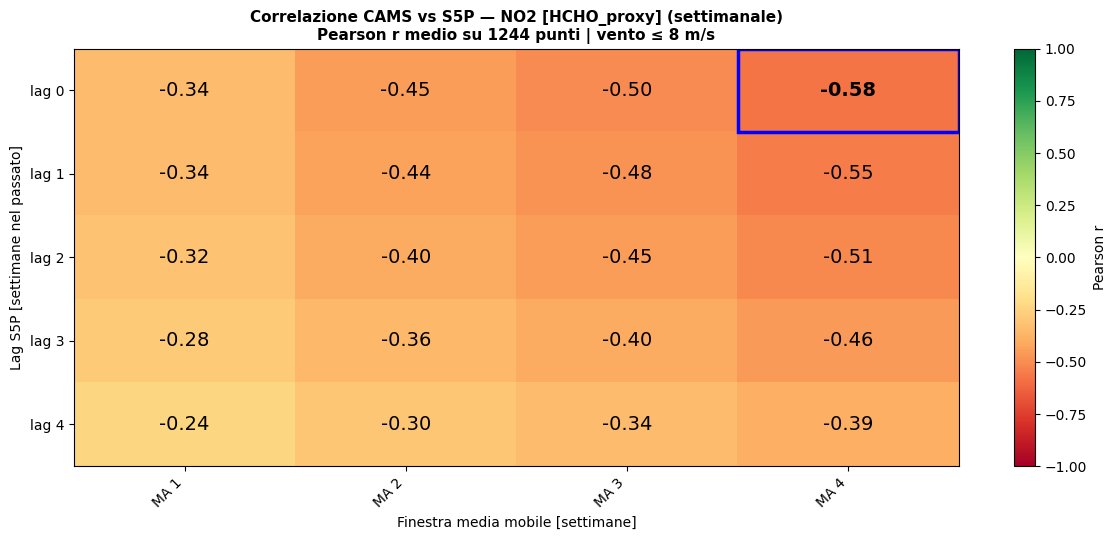

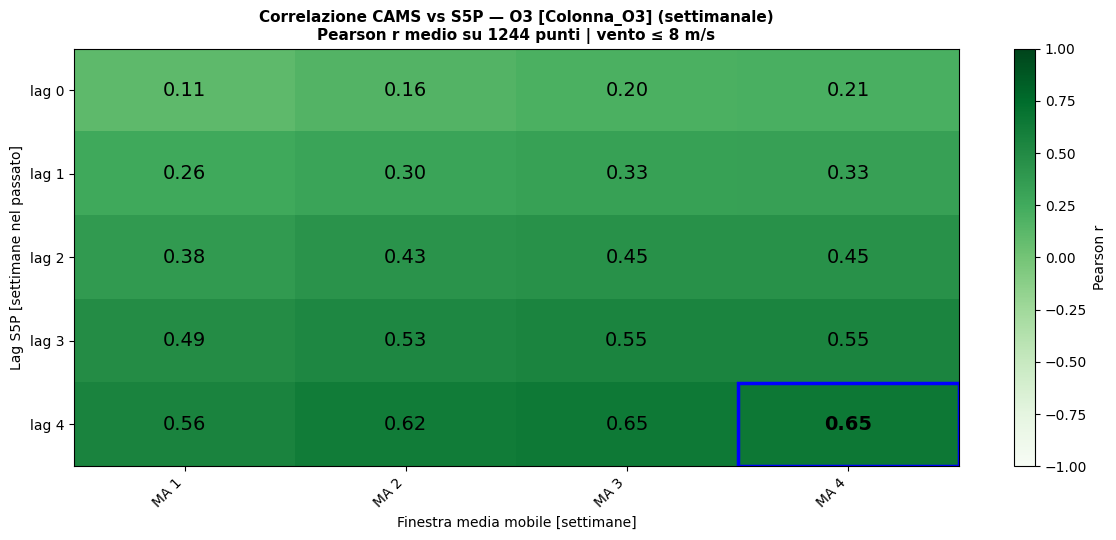

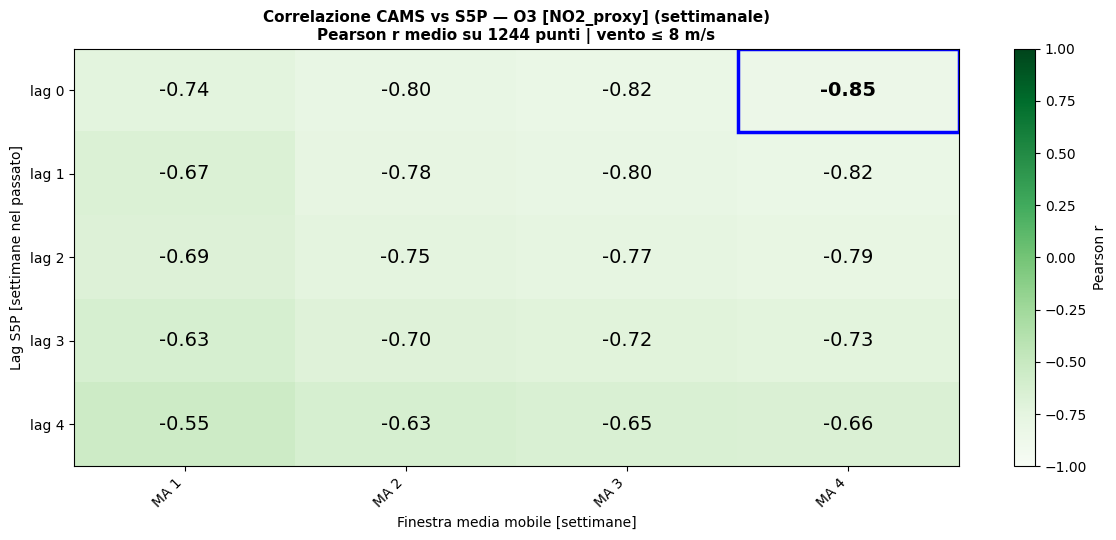

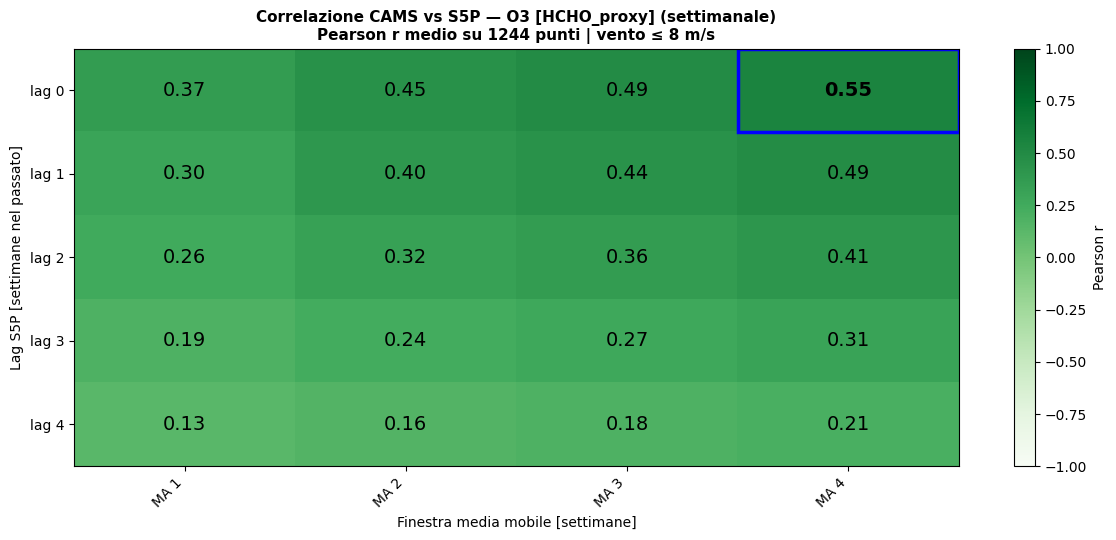

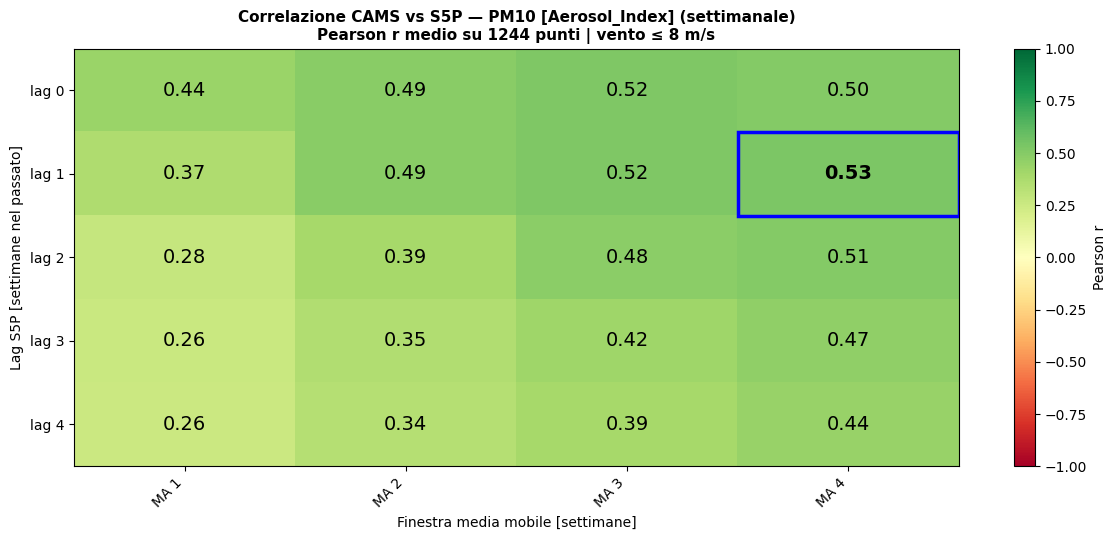

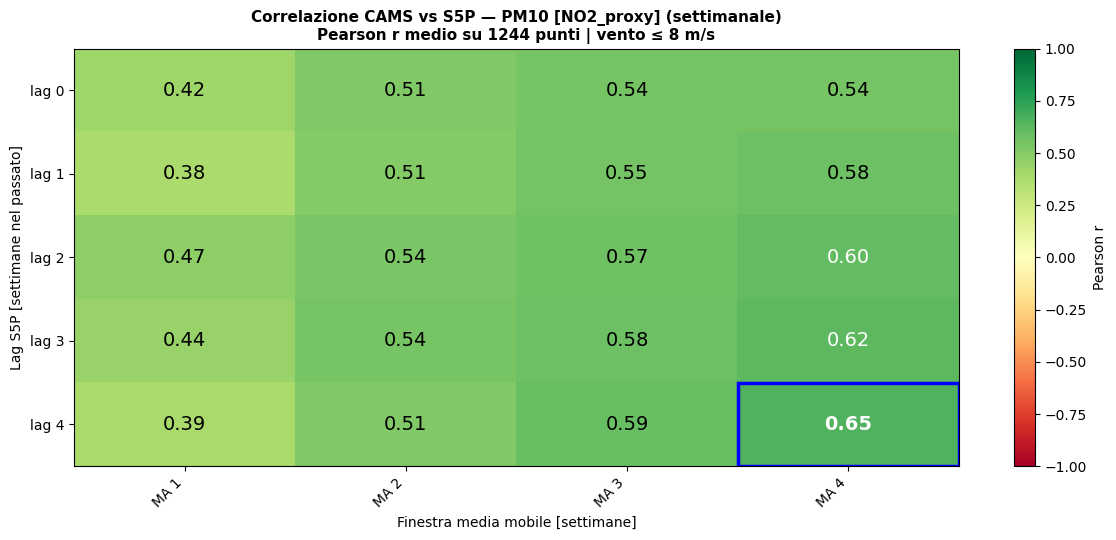

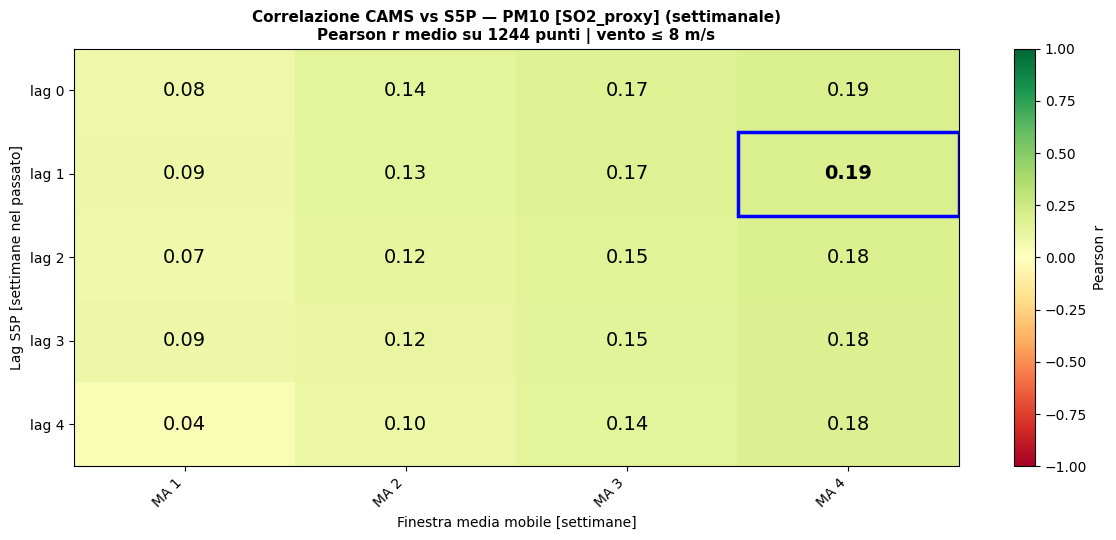

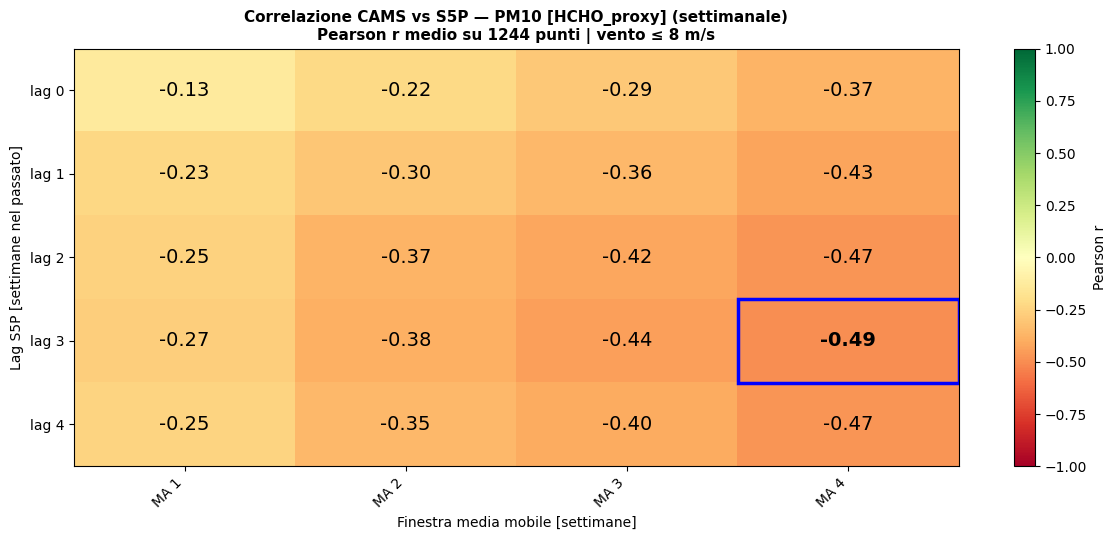

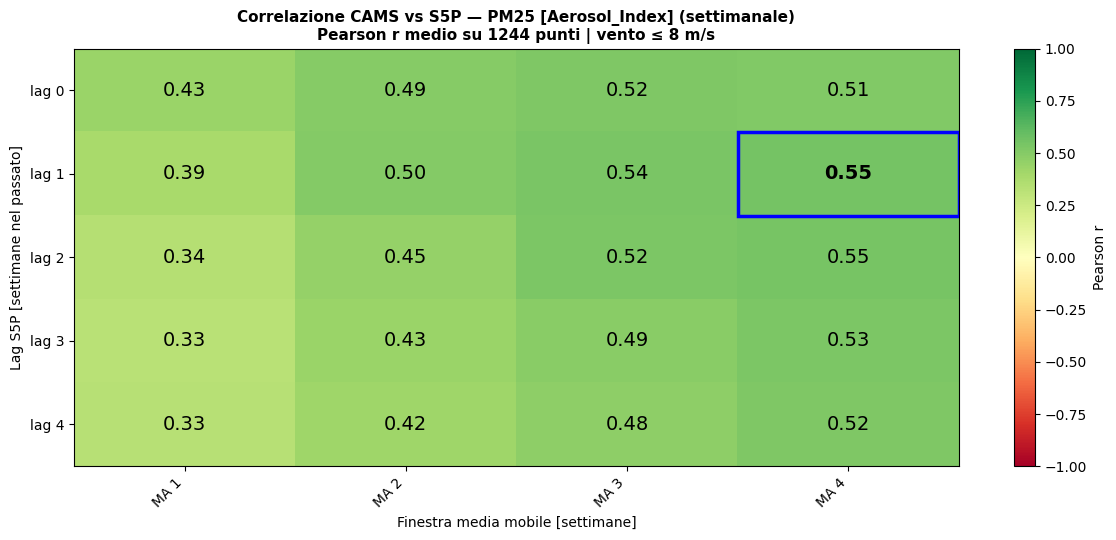

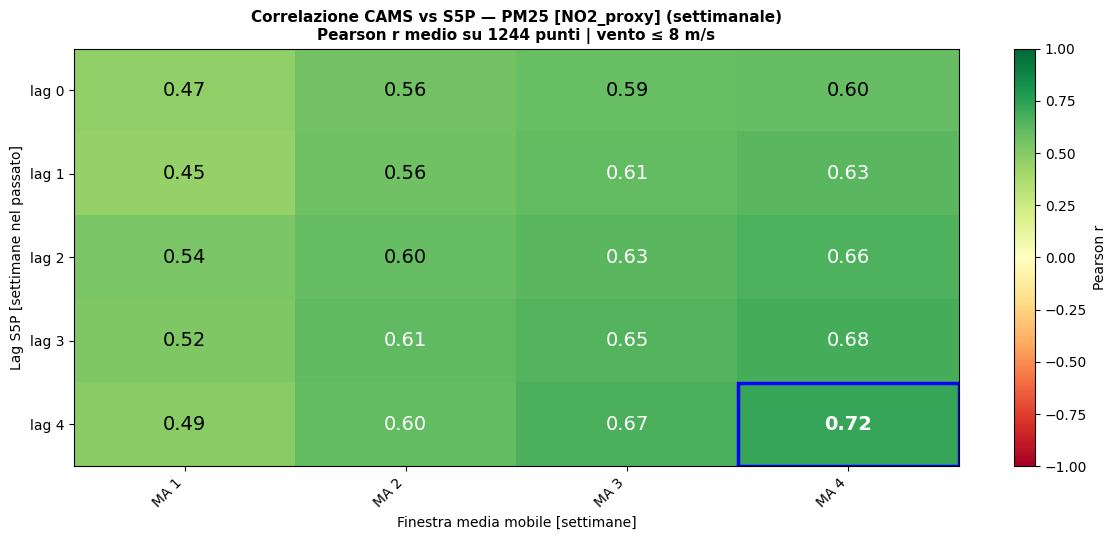

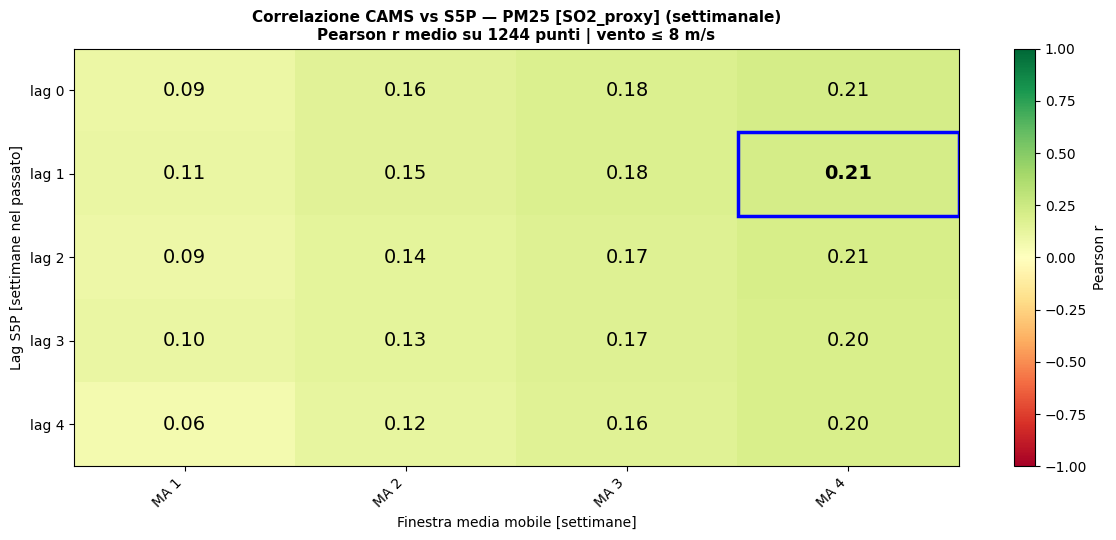

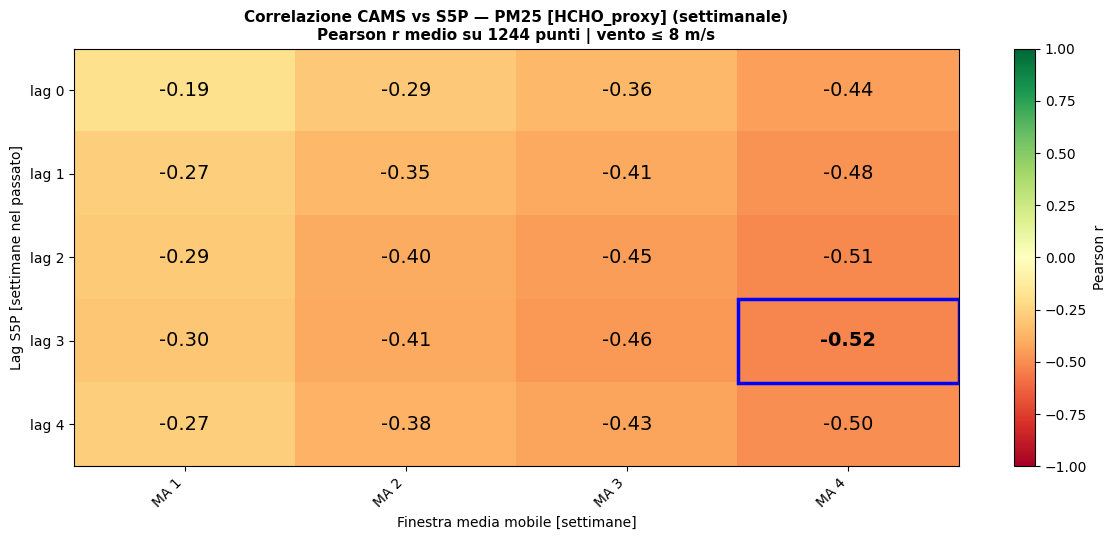

In [22]:
# ── Heatmap lag x MA (settimanale) per tutti i proxy testati
for chiave, df_ris in risultati_s.items():
    var_label, proxy_name = chiave
    if proxy_name == '_confronto_proxy':
        continue
    plot_matrice_lag_ma(df_ris, var_label, proxy_name, 'settimanale', unita='settimane')

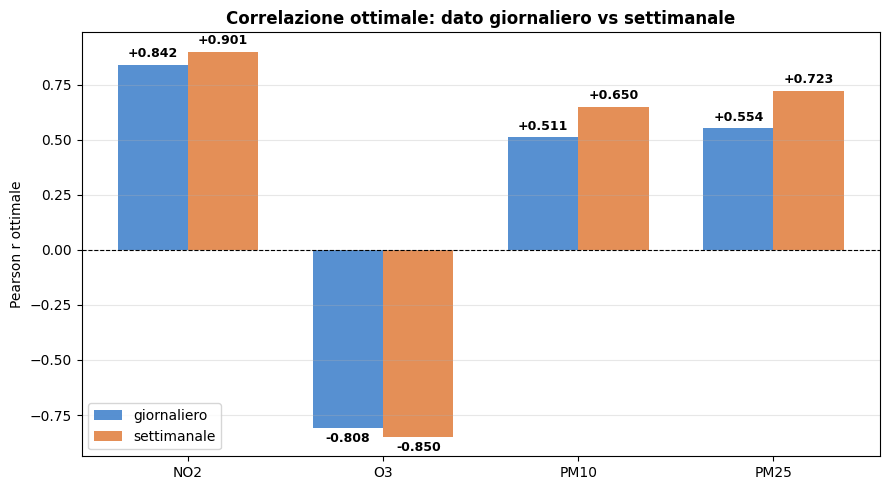

,variabile,proxy_ottimale_giorn,lag_ottimale_giorn,ma_ottimale_giorn,r_ottimale_giorn,proxy_ottimale_sett,lag_ottimale_sett,ma_ottimale_sett,r_ottimale_sett,delta_r
0,NO2,NO2_TROPOMI,7,14,0.8420,NO2_TROPOMI,2,4,0.9010,0.0590
1,O3,NO2_proxy,0,14,-0.8080,NO2_proxy,0,4,-0.8499,0.0419
2,PM10,Aerosol_Index,3,14,0.5110,NO2_proxy,4,4,0.6499,0.1389
3,PM25,NO2_proxy,7,14,0.5538,NO2_proxy,4,4,0.7230,0.1692


In [23]:
# ── Tabella di confronto giornaliero vs settimanale ──────────────────────────
confronto = riepilogo_g.merge(riepilogo_s, on='variabile',
                              suffixes=('_giorn', '_sett'))
confronto = confronto[['variabile',
                       'proxy_ottimale_giorn', 'lag_ottimale_giorn',
                       'ma_ottimale_giorn', 'r_ottimale_giorn',
                       'proxy_ottimale_sett', 'lag_ottimale_sett',
                       'ma_ottimale_sett', 'r_ottimale_sett']]
confronto['delta_r'] = (confronto['r_ottimale_sett'].abs()
                        - confronto['r_ottimale_giorn'].abs()).round(4)
confronto.to_csv(OUTPUT_DIR / 'confronto_giornaliero_settimanale.csv',
                 sep=';', decimal=',', index=False)

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(confronto))
larghezza = 0.36
ax.bar(xpos - larghezza / 2, confronto['r_ottimale_giorn'], larghezza,
       label='giornaliero', color='#3A7DC9', alpha=0.85)
ax.bar(xpos + larghezza / 2, confronto['r_ottimale_sett'], larghezza,
       label='settimanale', color='#E07B39', alpha=0.85)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xticks(xpos)
ax.set_xticklabels(confronto['variabile'])
ax.set_ylabel('Pearson r ottimale')
ax.set_title('Correlazione ottimale: dato giornaliero vs settimanale',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (rg, rs) in enumerate(zip(confronto['r_ottimale_giorn'],
                                 confronto['r_ottimale_sett'])):
    ax.text(i - larghezza / 2, rg + 0.02 * np.sign(rg), f'{rg:+.3f}',
            ha='center', va='bottom' if rg >= 0 else 'top', fontsize=9, fontweight='bold')
    ax.text(i + larghezza / 2, rs + 0.02 * np.sign(rs), f'{rs:+.3f}',
            ha='center', va='bottom' if rs >= 0 else 'top', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confronto_giornaliero_settimanale.png',
            dpi=150, bbox_inches='tight')
plt.show()

confronto

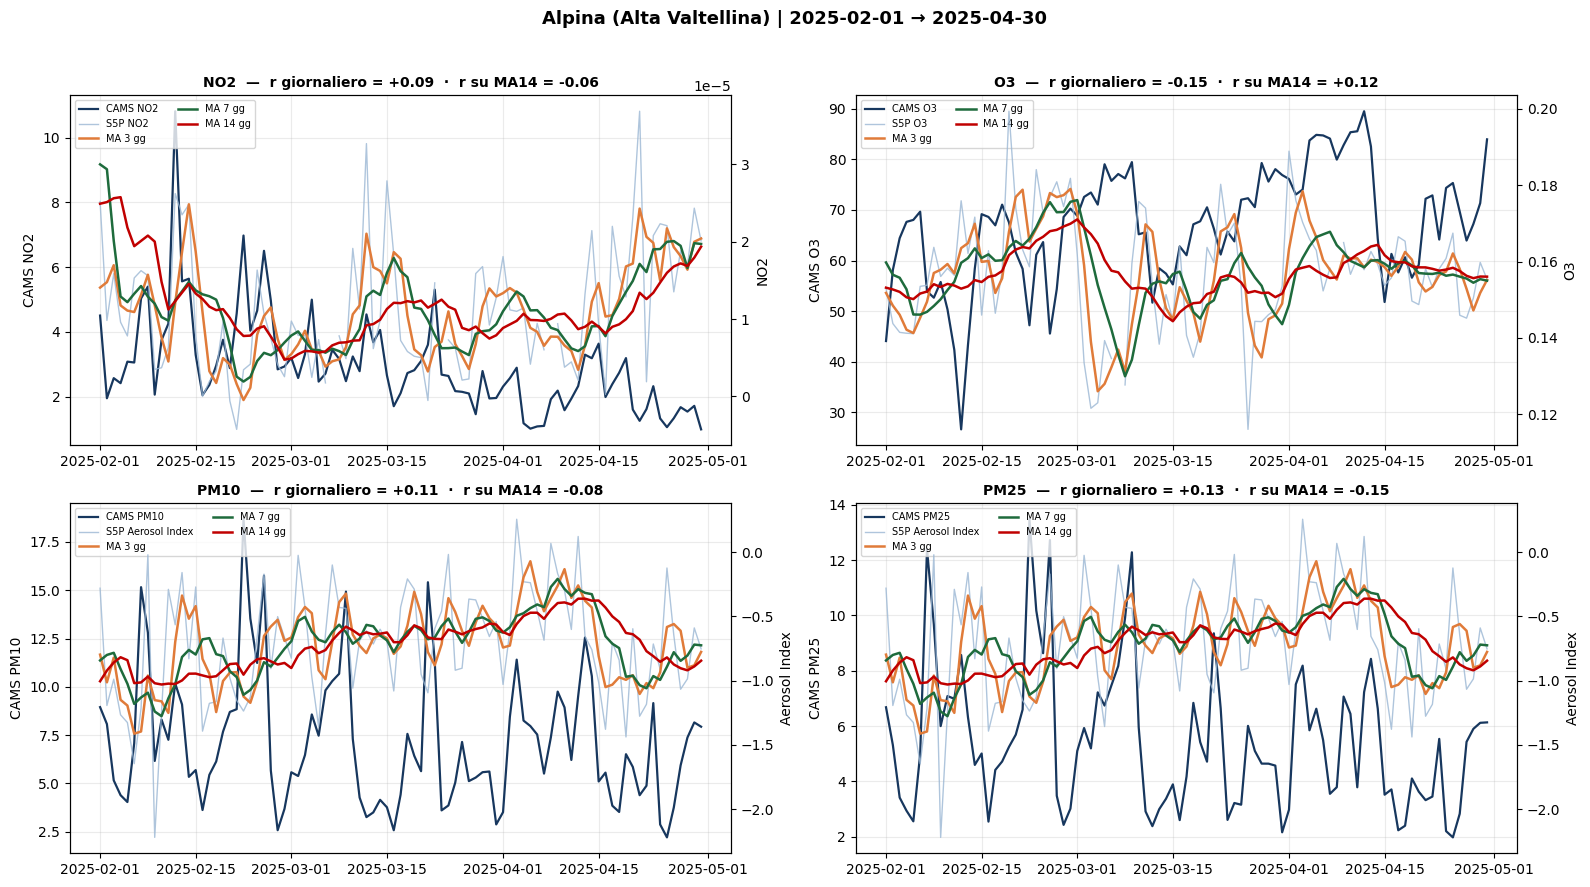

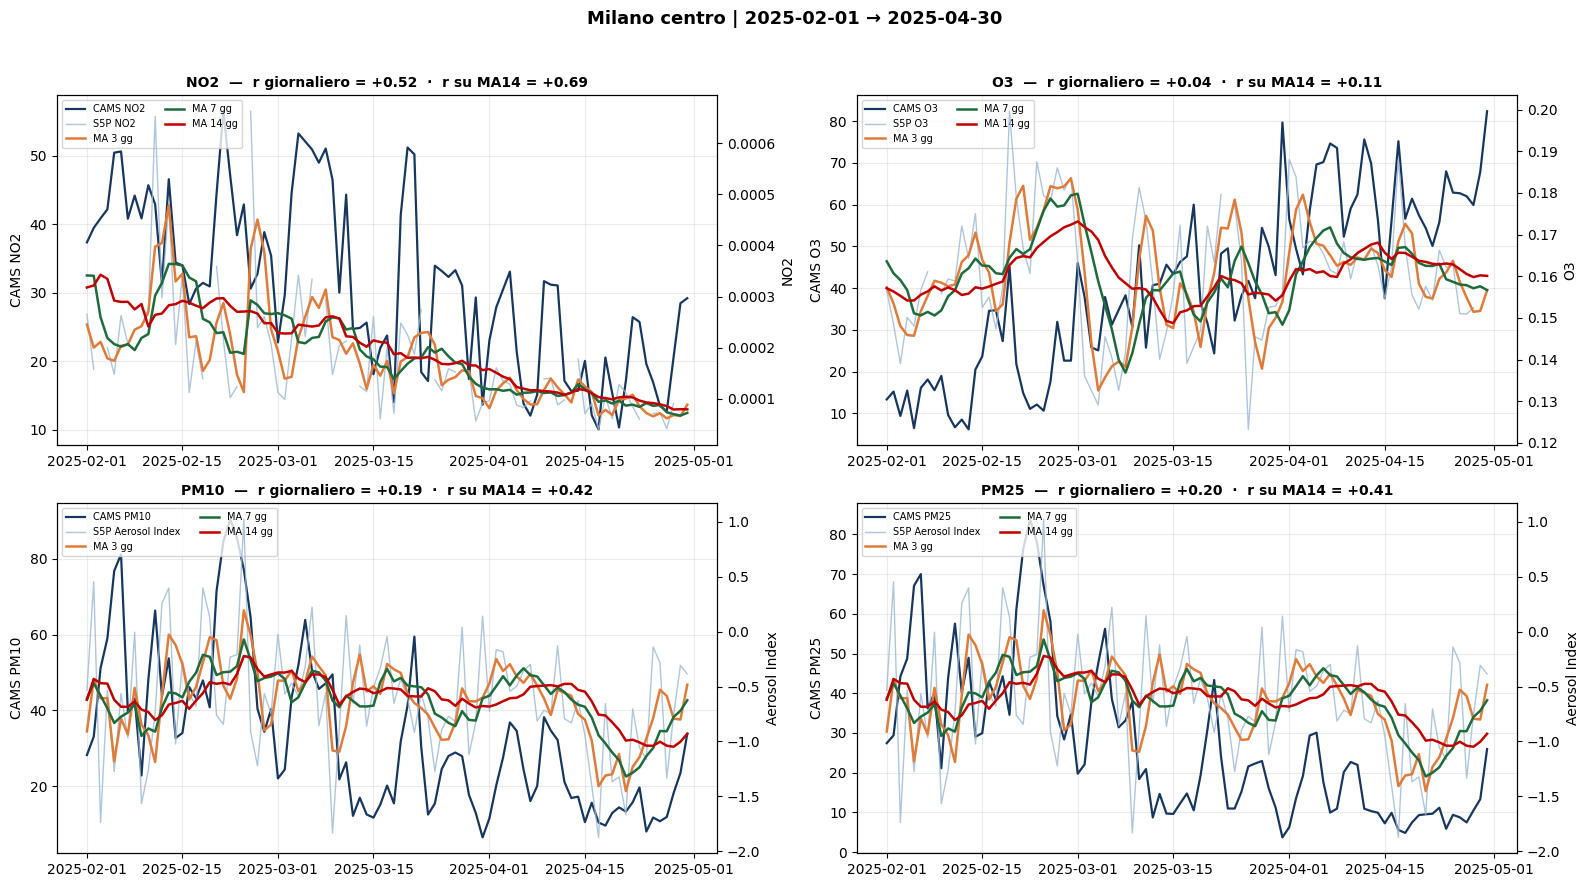

### Confronto giornaliero CAMS-S5P: Milano vs Rural

La tabella confronta, per ciascun inquinante, il coefficiente di correlazione di Pearson tra CAMS e S5P nel punto urbano di Milano e nel punto rurale di Alpina (periodo 2025-02-01 → 2025-04-30).

,Inquinante,Milan (r giornaliero),Rural (r giornaliero)
0,NO2,0.516,0.094
1,O3,0.038,-0.155
2,PM10,0.187,0.106
3,PM25,0.204,0.133


**Piccoli commenti**

- **NO2**: Milano +0.516, Rural +0.094 (Δ=+0.422) → correlazione più alta a Milano.

- **O3**: Milano +0.038, Rural -0.155 (Δ=+0.192) → correlazione più alta a Milano.

- **PM10**: Milano +0.187, Rural +0.106 (Δ=+0.081) → correlazione più alta a Milano.

- **PM25**: Milano +0.204, Rural +0.133 (Δ=+0.071) → correlazione più alta a Milano.

In [24]:
# Grafico temporale per punto: NO2, O3, PM10 e PM2.5
MA_WINDOWS_MAP = [3, 7, 14]
PUNTI_MAPPA = [
    {
        'punto_id': 15,
        'nome': 'Alpina (Alta Valtellina)',
        'file_tag': 'alpina_alta_valtellina',
        'tipo': 'Rural'
    },
    {
        'punto_id': 736,
        'nome': 'Milano centro',
        'file_tag': 'milano_centro',
        'tipo': 'Milan'
    },
]

MAPPA_INQUINANTI = [
    ('NO2', 'cams_no2', 's5p_no2', 'NO2', 'NO2'),
    ('O3', 'cams_o3', 's5p_o3', 'O3', 'O3'),
    ('PM10', 'cams_pm10', 's5p_pm10', 'PM10', 'Aerosol Index'),
    ('PM25', 'cams_pm25', 's5p_pm25', 'PM2.5', 'Aerosol Index'),
]


def plot_andamento_quattro_inquinanti(df, punto_id, nome_punto, file_tag, data_inizio, data_fine, cache):
    fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=False)
    righe_summary = []

    for ax, config in zip(axes.ravel(), MAPPA_INQUINANTI):
        var_label, cams_col, s5p_col, cams_label, s5p_label = config
        mask = (
            (df['punto_id'] == punto_id)
            & (df['data'] >= data_inizio)
            & (df['data'] <= data_fine)
        )

        df_sel = df.loc[mask, ['data', cams_col, s5p_col]].copy()
        if df_sel.empty:
            ax.set_axis_off()
            righe_summary.append({
                'Inquinante': var_label,
                'r_giornaliero': np.nan,
                'r_ma14': np.nan,
                'n_giornaliero': 0,
                'n_ma14': 0,
            })
            continue

        cams_raw = df_sel[cams_col].astype(float)
        s5p_raw = df_sel[s5p_col].astype(float)
        validi_giornalieri = cams_raw.notna() & s5p_raw.notna()
        n_giornaliero = int(validi_giornalieri.sum())
        r_giornaliero = cams_raw.corr(s5p_raw)

        ax2 = ax.twinx()
        ax.plot(df_sel['data'], cams_raw, color='#17375E', lw=1.6, label=f'CAMS {var_label}')
        ax2.plot(df_sel['data'], s5p_raw, color='#9BB7D4', lw=1.0, alpha=0.8, label=f'S5P {s5p_label}')

        r_ma14 = np.nan
        n_ma14 = 0
        colori_ma = {3: '#E07B39', 7: '#1E6B3C', 14: '#C00000'}
        for finestra in MA_WINDOWS_MAP:
            s5p_ma = media_mobile(df, s5p_col, finestra, cache).loc[mask]
            ax2.plot(df_sel['data'], s5p_ma, lw=1.8, color=colori_ma[finestra],
                     label=f'MA {finestra} gg')
            if finestra == 14:
                validi_ma14 = cams_raw.notna() & s5p_ma.notna()
                n_ma14 = int(validi_ma14.sum())
                r_ma14 = cams_raw.corr(s5p_ma)

        ax.set_title(f'{var_label}  —  r giornaliero = {r_giornaliero:+.2f}  ·  r su MA14 = {r_ma14:+.2f}',
                     fontsize=10, fontweight='bold')
        ax.set_ylabel(f'CAMS {var_label}')
        ax2.set_ylabel(s5p_label)
        ax.grid(alpha=0.25)

        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=7, ncol=2)

        righe_summary.append({
            'Inquinante': var_label,
            'r_giornaliero': r_giornaliero,
            'r_ma14': r_ma14,
            'n_giornaliero': n_giornaliero,
            'n_ma14': n_ma14,
        })

    fig.suptitle(f'{nome_punto} | {data_inizio.date()} → {data_fine.date()}',
                 fontsize=13, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(OUTPUT_DIR / f'andamento_{file_tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return pd.DataFrame(righe_summary)


cache_map = {}
summary_per_tipo = {}
for punto in PUNTI_MAPPA:
    df_sum = plot_andamento_quattro_inquinanti(
        df_g, punto['punto_id'], punto['nome'], punto['file_tag'],
        pd.Timestamp('2025-02-01'), pd.Timestamp('2025-04-30'), cache_map
    )
    summary_per_tipo[punto['tipo']] = df_sum.set_index('Inquinante')

# Tabella riassuntiva richiesta: solo colonne Milan/Rural giornaliere
if {'Milan', 'Rural'}.issubset(summary_per_tipo.keys()):
    from IPython.display import Markdown

    tabella_summary = pd.DataFrame(index=summary_per_tipo['Milan'].index)
    tabella_summary['Milan (r giornaliero)'] = summary_per_tipo['Milan']['r_giornaliero']
    tabella_summary['Rural (r giornaliero)'] = summary_per_tipo['Rural']['r_giornaliero']

    tabella_giornaliera = tabella_summary.reset_index()
    tabella_giornaliera.to_csv(OUTPUT_DIR / 'andamento_summary_milan_rural_giornaliero.csv',
                               sep=';', decimal=',', index=False)

    display(Markdown('### Confronto giornaliero CAMS-S5P: Milano vs Rural'))
    display(Markdown(
        'La tabella confronta, per ciascun inquinante, il coefficiente di correlazione di Pearson '
        'tra CAMS e S5P nel punto urbano di Milano e nel punto rurale di Alpina '
        '(periodo 2025-02-01 → 2025-04-30).'
    ))
    display(tabella_giornaliera.round(3))

    display(Markdown('**Piccoli commenti**'))
    for _, r in tabella_giornaliera.iterrows():
        mil = r['Milan (r giornaliero)']
        rur = r['Rural (r giornaliero)']
        if np.isnan(mil) or np.isnan(rur):
            commento = f"- **{r['Inquinante']}**: dati insufficienti per il confronto giornaliero."
        else:
            delta = mil - rur
            if abs(delta) < 0.05:
                confronto = 'valori simili tra Milano e Rural'
            elif delta > 0:
                confronto = 'correlazione più alta a Milano'
            else:
                confronto = 'correlazione più alta nel sito Rural'
            commento = (
                f"- **{r['Inquinante']}**: Milano {mil:+.3f}, Rural {rur:+.3f} "
                f"(Δ={delta:+.3f}) → {confronto}."
            )
        display(Markdown(commento))
else:
    print("Tabella Milan/Rural non creata: servono entrambi i tipi in PUNTI_MAPPA (Milan e Rural).")

## 11. Note per l'interpretazione dei risultati

- **Lag ottimale = 0** → il target CAMS del giorno *t* e l'osservazione satellitare dello stesso giorno sono coerenti: nessuno sfasamento temporale sistematico.
- **Lag ottimale > 0** → il Sentinel-5 dei giorni precedenti (*t−L*) è il miglior predittore del CAMS odierno: il segnale satellitare **anticipa** il valore del modello (persistenza dell'inquinante o tempi di trasporto).
- **Finestra MA ampia (7–14 giorni) ottimale** → il segnale giornaliero è dominato dal rumore meteorologico (nuvolosità, cambi di direzione del vento); la coerenza CAMS/S5P emerge solo su scale sinottiche. Atteso in particolare per NO₂.
- **Differenze tra settori di vento** → se un settore mostra r molto più alto/basso, la direzione di provenienza influenza la distribuzione degli inquinanti intorno alle sorgenti locali (es. aeroporti, aree industriali).
- **r pooled vs r medio per punto** (sezione 8) → se l'r pooled è molto più alto dell'r medio per punto, gran parte della correlazione è spiegata dal gradiente **spaziale** (punti inquinati vs puliti) e non dalla dinamica **temporale**.
- **Proxy PM** → non esistendo una misura satellitare diretta del particolato, il confronto tra Aerosol Index, NO₂, SO₂ e HCHO (sezione 7) indica quale colonna S5P è il miglior predittore indiretto di PM10/PM2.5 nell'area di studio.

**Output salvati in `risultati_correlazione/`:** matrici lag×MA (CSV+PNG) per ogni coppia inquinante/proxy, analisi per settore di vento, confronto proxy, grafici di dispersione con best fit, riepiloghi finali e confronto giornaliero/settimanale.